<a href="https://colab.research.google.com/github/daningMontano/ACUS_ECOSYSTEM_FUNCTION_ZCH/blob/main/Notebooks/Init_biophysical_charact/1_Base_line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initial biophysical characterization**

By: Daning Montaño
Date: 3/5/2026

This workbook provides basic information for characterizing ACUS ecosystems. It focuses on the use of GEE and remote sensing.

# **1. Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geemap
import ee
import math # Import the math module
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats

# **2. Initialize**

In [2]:
# Trigger the authentication flow.
#  Autenticar la cuenta de Google Earth Engine
ee.Authenticate()
ee.Initialize(project='monitoreofpachamama')

# **3. Data**

## 3.1. AOI

In [3]:
aoi =  ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh")
aoi_buffer_5km = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh_5km_buffer")
acus = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/ACUS_ZCH")

## 3.2. Remote sensing data

### DEM

30 meters

In [4]:
dem = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(dem)

### Precipitation

5.6 km

In [5]:
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
openland_precip = ee.Image("OpenLandMap/CLM/CLM_PRECIPITATION_SM2RAIN_M/v01")

### Temperature

MODIS: Surface temperature 1 km

In [45]:
# Definici!!n de fechas para el an!!lisis
start_date = '2000-01-01'
end_date = '2025-12-31'

# Relajamos el filtro de calidad para permitir m!!s datos en zonas nubosas
def mask_modis_quality_relaxed(image):
    qc_day = image.select('QC_Day')
    # Bitwise AND con 3 extrae bits 0-1.
    # 0: Good quality, 1: Other quality, 2: Suspect, 3: Not produced.
    # Permitimos calidad 0 y 1 (Good y Other) para obtener cobertura.
    mask_day = qc_day.bitwiseAnd(3).lte(1)
    return image.updateMask(mask_day)

modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate(start_date, end_date) \
    .select(['LST_Day_1km', 'QC_Day']) \
    .map(mask_modis_quality_relaxed)

print(f"Colección MODIS LST (Filtro relajado). Imágenes: {modis_lst.size().getInfo()}")

Colección MODIS LST (Filtro relajado). Imágenes: 1189


Landsat_ Surface temperature

In [58]:
# 1. Funciones para procesar temperatura superficial (LST) de Landsat (Colección 2 Nivel 2)
def prep_landsat_89(img):
    # Máscara de nubes usando QA_PIXEL (Bit 3 = Nubes, Bit 4 = Sombra de nubes)
    qa = img.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))

    # Extraer banda térmica (ST_B10) y aplicar factor de escala para LST
    # Factor de escala C2: ST * 0.00341802 + 149.0 (Kelvin). Restamos 273.15 para Celsius.
    st = img.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_Landsat')

    return st.updateMask(cloud_mask).copyProperties(img, ['system:time_start'])

def prep_landsat_57(img):
    qa = img.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))

    # Extraer banda térmica (ST_B6) y aplicar factor de escala
    st = img.select('ST_B6').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_Landsat')

    return st.updateMask(cloud_mask).copyProperties(img, ['system:time_start'])

# 2. Cargar colecciones filtradas por el AOI y aplicar procesamiento
print("Cargando colecciones de Landsat...")
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi).map(prep_landsat_89)
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi).map(prep_landsat_89)
l7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2").filterBounds(aoi).map(prep_landsat_57)
l5 = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2").filterBounds(aoi).map(prep_landsat_57)

# Unir todas las colecciones en una sola serie de tiempo histórica
landsat_lst_all = l5.merge(l7).merge(l8).merge(l9)

# 3. Calcular la Mediana Mensual (Dataset multianual mes a mes)
start_year = 1984 # Inicio de disponibilidad general Landsat 5
end_year = 2025
years = ee.List.sequence(start_year, end_year)
months = ee.List.sequence(1, 12)

def get_monthly_median(y):
    def calculate_month(m):
        # Filtrar la colección combinada por año y mes
        filtered = landsat_lst_all \
            .filter(ee.Filter.calendarRange(y, y, 'year')) \
            .filter(ee.Filter.calendarRange(m, m, 'month'))

        # Calcular la mediana píxel a píxel
        median_img = filtered.median() \
            .set('year', y) \
            .set('month', m) \
            .set('system:time_start', ee.Date.fromYMD(y, m, 1).millis())
        return median_img
    return months.map(calculate_month)

# Aplanar la lista de listas en una ImageCollection
landsat_monthly_lst = ee.ImageCollection.fromImages(years.map(get_monthly_median).flatten())

print(f"Colección Landsat LST Mensual creada.")

# Extraer las fechas reales desde la colección basándose en los resultados
first_date = ee.Date(landsat_monthly_lst.sort('system:time_start').first().get('system:time_start')).format('YYYY-MM-dd').getInfo()
last_date = ee.Date(landsat_monthly_lst.sort('system:time_start', False).first().get('system:time_start')).format('YYYY-MM-dd').getInfo()

print(f"El dataset contiene imágenes reales desde {first_date} hasta {last_date}.")
print(f"Total de imágenes en la colección mensual: {landsat_monthly_lst.size().getInfo()}")


Cargando colecciones de Landsat...
Colección Landsat LST Mensual creada.
El dataset contiene imágenes reales desde 1984-01-01 hasta 2025-12-01.
Total de imágenes en la colección mensual: 504


Temperature 2m

11.12 km

In [7]:
# Colección ERA5-LAND HOURLY
temperature_collection = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterBounds(aoi)
    .select("temperature_2m")
)
print(f"ERA5-LAND MONTHLY_AGGR collection filtered for AOI: {temperature_collection.size().getInfo()} images found.")

ERA5-LAND MONTHLY_AGGR collection filtered for AOI: 914 images found.


### MODIS

500 m

In [30]:
# Load MODIS NDVI collections (v061)
modis_terra = ee.ImageCollection('MODIS/061/MOD13A1').filterBounds(aoi)
modis_aqua = ee.ImageCollection('MODIS/061/MYD13Q1').filterBounds(aoi)

def mask_clouds_modis(img):
    # Obtener banda QA simplificada
    qa = img.select('SummaryQA')
    # En MODIS SummaryQA, 0 es 'Good Data' y 1 es 'Marginal Data'
    # Filtramos para quedarnos con datos confiables (bits 0 y 1)
    mask = qa.bitwiseAnd(3).lte(1)
    return img.updateMask(mask).select('EVI').divide(10000) \
              .copyProperties(img, ['system:time_start'])

# Aplicar máscara y combinar colecciones
filtered_terra = modis_terra.map(mask_clouds_modis)
filtered_aqua = modis_aqua.map(mask_clouds_modis)
merged_ndvi_collection = filtered_terra.merge(filtered_aqua).sort('system:time_start')

print(f"Colección NDVI procesada. Total de imágenes: {merged_ndvi_collection.size().getInfo()}")
print(f"Primer registro: {merged_ndvi_collection.first().date().format('YYYY-MM-DD').getInfo()}")

Colección NDVI procesada. Total de imágenes: 1150
Primer registro: 2000-02-49


# **4. Analysis**

## 4.1. Topographic

### DEM

In [9]:
dem_aoi = dem.clip(aoi)

## Map de DEM

# Define visualization parameters for the DEM
dem_vis_params = {
    'min': 0,
    'max': 4000,
    'palette': ['006633', 'E5FFCC', '662A00', '#FF8000', 'A6FFCC']
}

# Create a geemap.Map object
# Disable data controls to avoid fetching GOOGLE_MAPS_API_KEY outside Colab UI
map_dem = geemap.Map(data_ctrl=False)

# Add the clipped DEM layer to the map
map_dem.addLayer(dem_aoi, dem_vis_params, 'Digital Elevation Model')

# Create a styled layer for ACUS: outlines with a slight semi-transparent fill
# color: border color, fillColor: semi-transparent black (e.g., '00000033' for ~20% opacity)
acus_style = {'color': 'black', 'width': 1.5, 'fillColor': '00000033'}
map_dem.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

# Center the map on the AOI and display it
map_dem.centerObject(aoi, 9)
#map_dem

Plot Inside acus

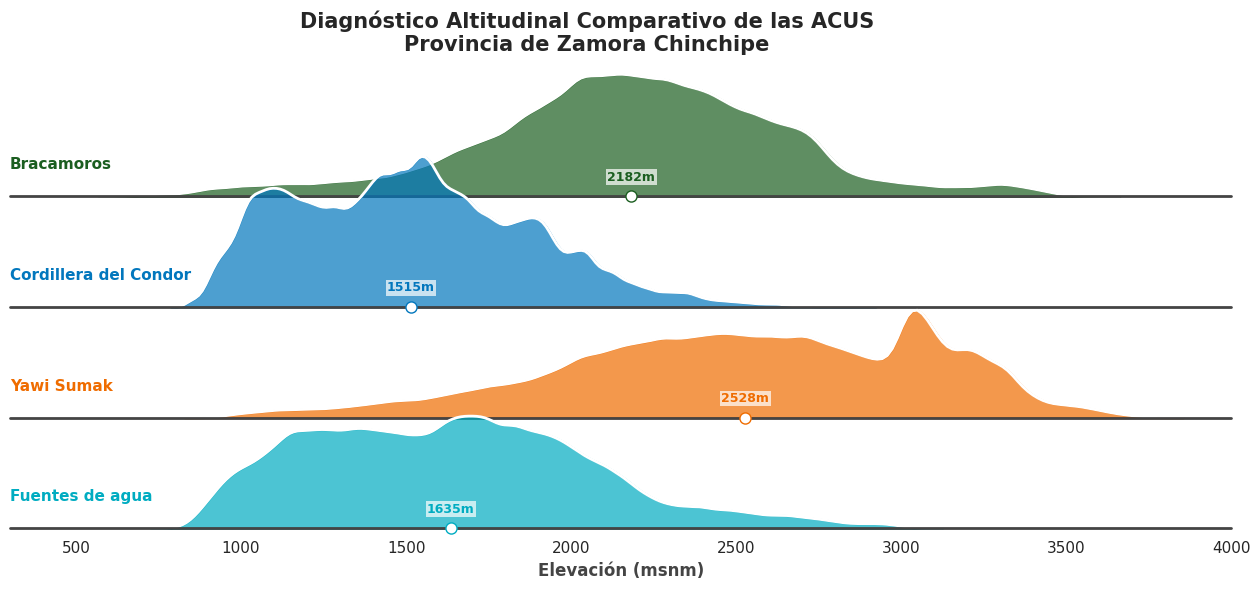

In [10]:

# 1. EXTRACCIÓN DE DATOS (Google Earth Engine)
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    values_list = dem.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('elevation').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'Elevacion': values_list, 'ACUS': nombre})
        all_data.append(df_temp)

df_plot = pd.concat(all_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

g.map(sns.kdeplot, "Elevacion", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "Elevacion", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO CORREGIDA
def annotate_assets(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media (en coordenadas de datos)
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media (ajustada para que coincida con el punto)
    ax.text(curr_mean, 0.0001, f'{curr_mean:.0f}m', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_assets, "Elevacion")

# 4. REFINAMIENTO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(300, 4000))
g.despine(bottom=True, left=True)

plt.xlabel("Elevación (msnm)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Diagnóstico Altitudinal Comparativo de las ACUS\nProvincia de Zamora Chinchipe',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [11]:
# Calcular estadísticas principales del DEM para cada ACUS
stats_list = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor combinado para eficiencia (corregido: se eliminó el argumento 'reducer=')
    reducers = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), '', True) \
        .combine(ee.Reducer.min(), '', True) \
        .combine(ee.Reducer.max(), '', True)

    stats = dem.reduceRegion(
        reducer=reducers,
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).getInfo()

    if stats:
        stats_list.append({
            'ACUS': nombre,
            'Mínimo (msnm)': stats.get('elevation_min'),
            'Máximo (msnm)': stats.get('elevation_max'),
            'Media (msnm)': round(stats.get('elevation_mean'), 2),
            'Desv. Estándar': round(stats.get('elevation_stdDev'), 2)
        })

# Crear DataFrame y mostrar tabla
df_stats_dem = pd.DataFrame(stats_list)

# Estilizar la tabla para el reporte
print("Principales Estadísticas Altimétricas por ACUS")
display(df_stats_dem.style.background_gradient(subset=['Media (msnm)'], cmap='YlGnBu').format(precision=2))

Principales Estadísticas Altimétricas por ACUS


,ACUS,Mínimo (msnm),Máximo (msnm),Media (msnm),Desv. Estándar
0,Bracamoros,634,3587,2182.25,464.63
1,Cordillera del Condor,839,2866,1514.58,357.02
2,Yawi Sumak,904,3774,2528.12,548.52
3,Fuentes de agua,812,3061,1635.50,430.20


### Slope

In [12]:
slope_aoi = slope.clip(aoi)

# Define visualization parameters for the slope
slope_vis_params = {
    'min': 0,
    'max': 60,
    'palette': ['3ae237', 'b5c225', 'fd9122', 'ef8a33', 'ff0000']
}

# Create a geemap.Map object
# Fix: Remove the invalid string-based basemap parameter
map_slope = geemap.Map(data_ctrl=False)

# Add the clipped slope layer to the map
map_slope.addLayer(slope_aoi, slope_vis_params, 'Slope')

# Create a styled layer for ACUS: outlines with a slight semi-transparent fill
acus_style = {'color': 'black', 'width': 1.5, 'fillColor': '00000033'}
map_slope.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

# Center the map on the AOI and display it
map_slope.centerObject(aoi, 9)
#map_slope

Slope Inside ACUS

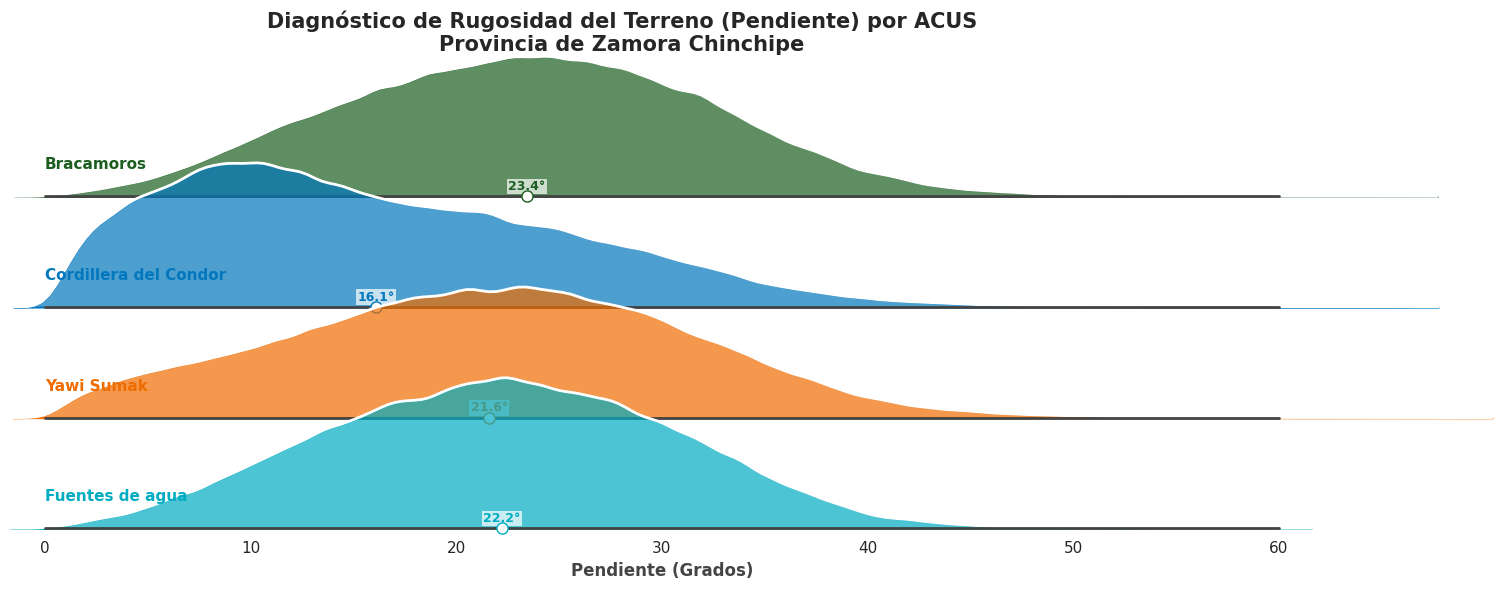

In [13]:
# 1. EXTRACCIÓN DE DATOS DE PENDIENTE (Google Earth Engine)
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_slope_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    # Extraer valores de pendiente (slope)
    values_list = slope.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('slope').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'Pendiente': values_list, 'ACUS': nombre})
        all_slope_data.append(df_temp)

df_plot_slope = pd.concat(all_slope_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot_slope, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

# Mapeo de densidades
g.map(sns.kdeplot, "Pendiente", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "Pendiente", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO (Adaptada para Pendiente)
def annotate_slope(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media
    ax.text(curr_mean, 0.001, f'{curr_mean:.1f}°', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_slope, "Pendiente")

# 4. REFINAMIENTO ESTÉTICO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(0, 60)) # Rango típico de pendiente en grados
g.despine(bottom=True, left=True)

plt.xlabel("Pendiente (Grados)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Diagnóstico de Rugosidad del Terreno (Pendiente) por ACUS\nProvincia de Zamora Chinchipe',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [14]:
# Calcular estadísticas principales de la Pendiente para cada ACUS
stats_slope_list = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor combinado para estadísticas de pendiente
    reducers = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), '', True) \
        .combine(ee.Reducer.min(), '', True) \
        .combine(ee.Reducer.max(), '', True)

    stats = slope.reduceRegion(
        reducer=reducers,
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).getInfo()

    if stats:
        stats_slope_list.append({
            'ACUS': nombre,
            'Mínimo (°)': stats.get('slope_min'),
            'Máximo (°)': stats.get('slope_max'),
            'Media (°)': round(stats.get('slope_mean'), 2),
            'Desv. Estándar (°)': round(stats.get('slope_stdDev'), 2)
        })

# Crear DataFrame y mostrar tabla
df_stats_slope = pd.DataFrame(stats_slope_list)

# Estilizar la tabla para el reporte
print("Principales Estadísticas de Pendiente por ACUS")
display(df_stats_slope.style.background_gradient(subset=['Media (°)'], cmap='YlOrRd').format(precision=2))

Principales Estadísticas de Pendiente por ACUS


,ACUS,Mínimo (°),Máximo (°),Media (°),Desv. Estándar (°)
0,Bracamoros,0,66.26,23.43,8.84
1,Cordillera del Condor,0,66.22,16.10,9.55
2,Yawi Sumak,0,68.83,21.60,9.58
3,Fuentes de agua,0,59.86,22.20,8.42


### Slope classification

| Clase | Pendiente (grados) | Interpretación          |
| ----- | -----------------: | ----------------------- |
| 1     |               0–1° | Plano                   |
| 2     |               1–3° | Ligeramente inclinado   |
| 3     |               3–7° | Suavemente ondulado     |
| 4     |              7–14° | Moderadamente inclinado |
| 5     |             14–27° | Fuertemente inclinado   |
| 6     |             27–37° | Escarpado               |
| 7     |               >37° | Muy escarpado           |


In [15]:
# Function to classify slope based on criteria (slope in degrees)

def classify_slope(image):
    # The input 'image' is already in degrees, no conversion needed for classification by degrees.

    # Initialize classified_slope as an unmasked image with a default value (e.g., 0).
    # Then, apply classification rules using .where().
    classified_slope = ee.Image.constant(0).rename('Slope_Class_Degrees')

    # Classify the slope degree values using .where() for each condition
    classified_slope = classified_slope.where(image.lte(1), 1) # Class 1: 0-1°
    classified_slope = classified_slope.where(image.gt(1).And(image.lte(3)), 2) # Class 2: 1-3°
    classified_slope = classified_slope.where(image.gt(3).And(image.lte(7)), 3) # Class 3: 3-7°
    classified_slope = classified_slope.where(image.gt(7).And(image.lte(14)), 4) # Class 4: 7-14°
    classified_slope = classified_slope.where(image.gt(14).And(image.lte(27)), 5) # Class 5: 14-27°
    classified_slope = classified_slope.where(image.gt(27).And(image.lte(37)), 6) # Class 6: 27-37°
    classified_slope = classified_slope.where(image.gt(37), 7) # Class 7: >37°

    return classified_slope

# Apply the classification function to the clipped slope image
classified_slope_aoi = classify_slope(slope_aoi)
classified_slope_aoi = classified_slope_aoi.clip(aoi)
# Define visualization parameters for the classified slope
slope_class_vis = {
    'min': 1,
    'max': 7,
    'palette': [
        '#006837',  # Class 1: 0-1° (Plano)
        '#1a9850',  # Class 2: 1-3° (Ligeramente inclinado)
        '#66bd63',  # Class 3: 3-7° (Suavemente ondulado)
        '#d9ef8b',  # Class 4: 7-14° (Moderadamente inclinado)
        '#fee08b',  # Class 5: 14-27° (Fuertemente inclinado)
        '#fc8d59',  # Class 6: 27-37° (Escarpado)
        '#d73027'   # Class 7: >37° (Muy escarpado)
    ]
}

# Create a geemap.Map object
map_classified_slope = geemap.Map()

# Add the classified slope layer to the map
map_classified_slope.addLayer(classified_slope_aoi, slope_class_vis, 'Slope Classification (Degrees)')

# Center the map on the AOI and display it
map_classified_slope.centerObject(aoi, 9)
#map_classified_slope

Slope classes inside ACUS

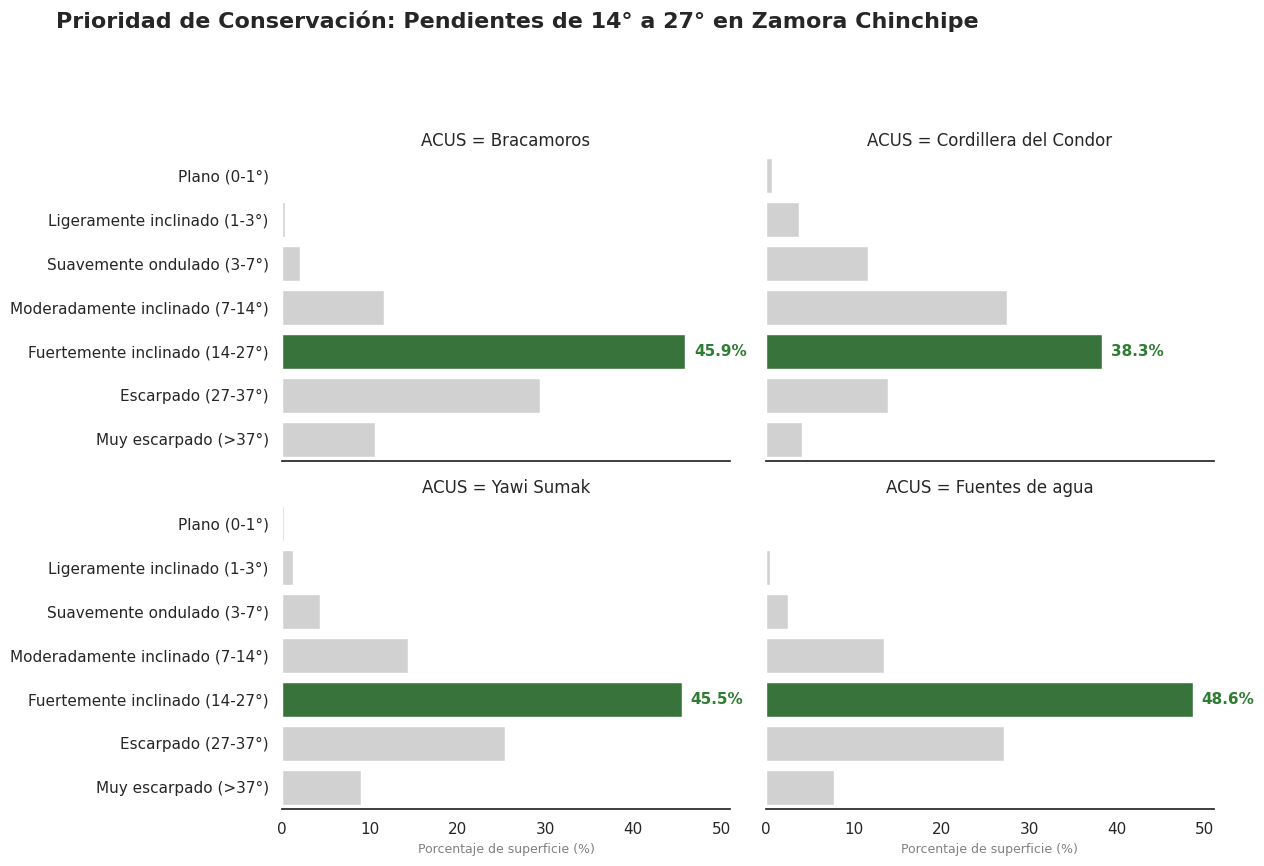

In [16]:
# --- CONFIGURACIÓN DE CLASES ---
# Definición de nombres y orden para las clases de pendiente
slope_class_names = {
    1: 'Plano (0-1°)',
    2: 'Ligeramente inclinado (1-3°)',
    3: 'Suavemente ondulado (3-7°)',
    4: 'Moderadamente inclinado (7-14°)',
    5: 'Fuertemente inclinado (14-27°)',
    6: 'Escarpado (27-37°)',
    7: 'Muy escarpado (>37°)'
}

ordered_slope_classes = [
    'Plano (0-1°)', 'Ligeramente inclinado (1-3°)', 'Suavemente ondulado (3-7°)',
    'Moderadamente inclinado (7-14°)', 'Fuertemente inclinado (14-27°)',
    'Escarpado (27-37°)', 'Muy escarpado (>37°)'
]

# --- FASE 1: ADQUIRIR Y ANALIZAR (Extracción de Datos GEE) ---
data_list = []
for nombre in nombres_categorias:
    geom = acus.filter(ee.Filter.eq('Nombre', nombre)).geometry()
    hist = classified_slope_aoi.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geom,
        scale=30,
        maxPixels=1e9
    ).get('Slope_Class_Degrees').getInfo()

    if hist:
        total_pixels = sum(hist.values())
        for class_id_str, count in hist.items():
            class_id = int(float(class_id_str))
            if class_id in slope_class_names:
                data_list.append({
                    'ACUS': nombre,
                    'Clase': slope_class_names[class_id],
                    'Porcentaje': (count / total_pixels) * 100
                })

df = pd.DataFrame(data_list)
df['Clase'] = pd.Categorical(df['Clase'], categories=ordered_slope_classes, ordered=True)

# --- FASE 2: REPRESENTAR Y REFINAR (Visualización Explicativa) ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
main_class = 'Fuertemente inclinado (14-27°)'

g = sns.FacetGrid(df, col='ACUS', col_wrap=2, height=4, aspect=1.6, sharex=True)

def draw_refined_bars(data, **kwargs):
    ax = plt.gca()
    colors = ['#2E7D32' if c == main_class else '#D1D1D1' for c in data['Clase']]
    sns.barplot(data=data, y='Clase', x='Porcentaje', palette=colors, ax=ax, hue='Clase', legend=False)

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if i < len(data):
            class_name = data['Clase'].iloc[i]
            if class_name == main_class:
                ax.text(width + 1, i, f'{width:.1f}%', va='center', fontsize=11, color='#2E7D32', fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('Porcentaje de superficie (%)', fontsize=9, color='gray')

g.map_dataframe(draw_refined_bars)

# --- FASE 3: DELIVER ---
g.fig.suptitle('Prioridad de Conservación: Pendientes de 14° a 27° en Zamora Chinchipe', fontsize=16, fontweight='bold', x=0.05, ha='left', y=1.08)
plt.tight_layout()
plt.show()

### Length and slope angle (LS)

Cálculo del factor topográfico LS según Renard et al. (1997)

El factor LS representa el efecto combinado de la longitud de pendiente y la inclinación del terreno sobre el potencial de erosión hídrica en el modelo RUSLE.

La formulación general es:

$$
LS = L \times S
$$

donde \(L\) es el factor de longitud de pendiente y \(S\) es el factor de inclinación de pendiente.

Factor de longitud de pendiente

$$
L = \left(\frac{\lambda}{22.13}\right)^m
$$

donde:

$$
m = \frac{\beta}{1+\beta}
$$

$$
\beta =
\frac{
\left(\frac{\sin\theta}{0.0896}\right)
}{
3.0(\sin\theta)^{0.8}+0.56
}
$$

Factor de inclinación de pendiente

$$
S =
\begin{cases}
10.8\sin\theta + 0.03, & \text{si la pendiente} < 9\% \\
16.8\sin\theta - 0.50, & \text{si la pendiente} \geq 9\%
\end{cases}
$$

Fórmula completa

$$
LS =
\left(\frac{\lambda}{22.13}\right)^m
\times
\begin{cases}
10.8\sin\theta + 0.03, & \text{si la pendiente} < 9\% \\
16.8\sin\theta - 0.50, & \text{si la pendiente} \geq 9\%
\end{cases}
$$

con:

$$
m = \frac{\beta}{1+\beta}
$$

$$
\beta =
\frac{
\left(\frac{\sin\theta}{0.0896}\right)
}{
3.0(\sin\theta)^{0.8}+0.56
}
$$

Aplicación usada en este análisis

En este caso se usa la longitud estándar de parcela del modelo USLE/RUSLE:

$$
\lambda = 22.13 \ \text{m}
$$

Por tanto:

$$
L =
\left(\frac{22.13}{22.13}\right)^m = 1
$$

Entonces, el factor LS queda definido principalmente por el componente de inclinación de pendiente:

$$
LS = S
$$

Variables

| Símbolo | Significado |
|---|---|
| \(LS\) | Factor topográfico del modelo RUSLE |
| \(L\) | Factor de longitud de pendiente |
| \(S\) | Factor de inclinación de pendiente |
| \(\lambda\) | Longitud de pendiente en metros |
| \(22.13\) | Longitud estándar de la parcela USLE/RUSLE, en metros |
| \(\theta\) | Ángulo de pendiente en radianes |
| \(\sin\theta\) | Seno del ángulo de pendiente |
| \(m\) | Exponente de longitud de pendiente |
| \(\beta\) | Relación entre erosión en surcos e intersurcos |

In [17]:
# -------------------------------------------------------
# 1. Insumos requeridos
# -------------------------------------------------------
# Se asume que ya tienes:
# aoi       = área de estudio
# dem_aoi   = DEM recortado al área de estudio
# slope_aoi = pendiente en grados

# Pendiente en grados
slope_deg = slope_aoi.rename("slope_deg")

# Pendiente en radianes
slope_rad = slope_deg.multiply(math.pi).divide(180).rename("slope_rad")

# Seno de la pendiente
sin_theta = slope_rad.sin().rename("sin_theta")

# Pendiente en porcentaje
slope_pct = slope_rad.tan().multiply(100).rename("slope_pct")

# -------------------------------------------------------
# 2. Longitud de pendiente lambda
# -------------------------------------------------------
# Opción conservadora:
# usar la longitud estándar RUSLE = 22.13 m.
# Esto hace que L sea cercano a 1 y evita inflar el LS con acumulación de flujo.

lambda_img = ee.Image.constant(22.13).rename("lambda_m").clip(aoi)

# Si en el futuro tienes una capa real de longitud de pendiente,
# reemplaza la línea anterior por algo como:
# lambda_img = ee.Image("projects/tu_proyecto/assets/lambda_ladera").clip(aoi).rename("lambda_m")

# -------------------------------------------------------
# 3. Cálculo del exponente m
# -------------------------------------------------------
# beta = (sin(theta) / 0.0896) / [3.0 * sin(theta)^0.8 + 0.56]

beta = sin_theta.divide(0.0896).divide(
    sin_theta.pow(0.8).multiply(3.0).add(0.56)
).rename("beta")

# m = beta / (1 + beta)
m = beta.divide(beta.add(1)).rename("m")

# -------------------------------------------------------
# 4. Factor L
# -------------------------------------------------------
# L = (lambda / 22.13)^m

L = lambda_img.divide(22.13).pow(m).rename("L_Renard_1997")

# -------------------------------------------------------
# 5. Factor S
# -------------------------------------------------------
# Renard et al. 1997:
# si pendiente < 9%  -> S = 10.8 sin(theta) + 0.03
# si pendiente >= 9% -> S = 16.8 sin(theta) - 0.50

S_low = sin_theta.multiply(10.8).add(0.03)
S_high = sin_theta.multiply(16.8).subtract(0.50)

S = ee.Image(0) \
    .where(slope_pct.lt(9), S_low) \
    .where(slope_pct.gte(9), S_high) \
    .rename("S_Renard_1997")

# Evitar valores negativos de S en zonas casi planas
S = S.max(0.03).rename("S_Renard_1997")

# -------------------------------------------------------
# 6. Factor LS final
# -------------------------------------------------------

LS_Renard = L.multiply(S) \
    .rename("LS_Renard_1997") \
    .updateMask(dem_aoi.mask())



# -------------------------------------------------------
# 9. Visualización
# -------------------------------------------------------

map_ls_renard = geemap.Map(data_ctrl=False)
map_ls_renard.centerObject(aoi, 9)

ls_palette = ["#ffffcc", "#fecc5c", "#fd8d3c", "#e31a1c", "#800026"]

map_ls_renard.addLayer(
    slope_deg.clip(aoi),
    {
        "min": 0,
        "max": 45,
        "palette": ["#ffffcc", "#fd8d3c", "#800026"]
    },
    "Pendiente grados"
)

map_ls_renard.addLayer(
    L.clip(aoi),
    {
        "min": 0,
        "max": 5,
        "palette": ["#ffffcc", "#a1dab4", "#225ea8"]
    },
    "L Renard et al. 1997"
)

map_ls_renard.addLayer(
    S.clip(aoi),
    {
        "min": 0,
        "max": 10,
        "palette": ["#ffffcc", "#fd8d3c", "#bd0026"]
    },
    "S Renard et al. 1997"
)

map_ls_renard.addLayer(
    LS_Renard.clip(aoi),
    {
        "min": 0,
        "max": 14,
        "palette": ls_palette
    },
    "LS Renard et al. 1997"
)

map_ls_renard.addLayer(
    acus.style(**acus_style),
    {},
    "Límites ACUS"
)

#map_ls_renard

Inside Acus

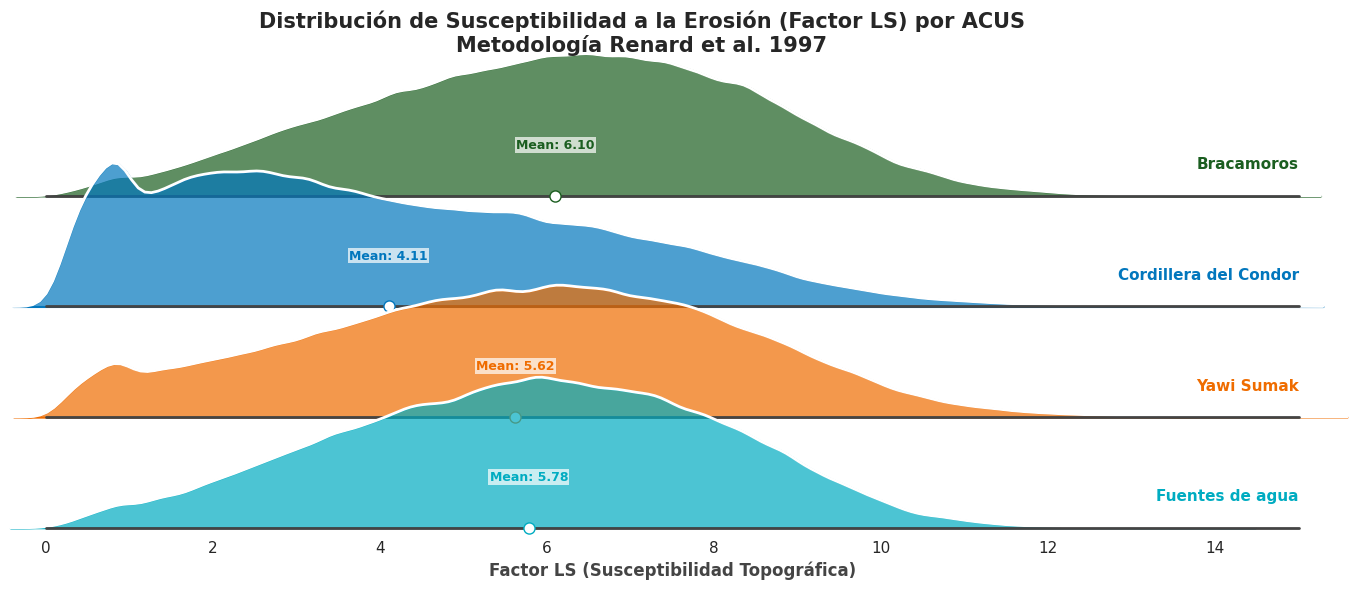

In [18]:

# 1. EXTRACCIÓN DE DATOS DEL FACTOR LS (Google Earth Engine)
# Usamos la variable LS_Renard definida anteriormente
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_ls_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    # Extraer valores del Factor LS
    values_list = LS_Renard.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('LS_Renard_1997').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'LS_Factor': values_list, 'ACUS': nombre})
        all_ls_data.append(df_temp)

df_plot_ls = pd.concat(all_ls_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot_ls, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

# Mapeo de densidades (KDE)
g.map(sns.kdeplot, "LS_Factor", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "LS_Factor", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO MODIFICADA (Nombres a la derecha)
def annotate_ls(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS a la derecha (x=1 en transformAxes)
    ax.text(1, 0.2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media
    ax.text(curr_mean, 0.05, f'Mean: {curr_mean:.2f}', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_ls, "LS_Factor")

# 4. REFINAMIENTO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(0, 15)) # Limitar a 15 ya que es el rango típico calculado
g.despine(bottom=True, left=True)

plt.xlabel("Factor LS (Susceptibilidad Topográfica)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Distribución de Susceptibilidad a la Erosión (Factor LS) por ACUS\nMetodología Renard et al. 1997',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [19]:

# Consolidar estadísticas de LS
ls_summary_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor para el Factor LS
    # Usamos LS_Renard que es la variable definida en la celda anterior
    ls_stats = LS_Renard.reduceRegion(
            reducer=ee.Reducer.mean().combine(ee.Reducer.min(), '', True).combine(ee.Reducer.max(), '', True),
            geometry=subset.geometry(),
            scale=90,
            maxPixels=1e9
        ).getInfo()

    # Verificamos que las llaves existan y no sean None antes de redondear
    if ls_stats and ls_stats.get('LS_Renard_1997_mean') is not None:
        ls_summary_data.append({
            'ACUS': nombre,
            'LS Mínimo': round(ls_stats.get('LS_Renard_1997_min'), 2),
            'LS Máximo': round(ls_stats.get('LS_Renard_1997_max'), 2),
            'LS Medio': round(ls_stats.get('LS_Renard_1997_mean'), 2)
        })

# Crear el DataFrame de resumen de LS
df_ls_summary = pd.DataFrame(ls_summary_data)

# Mostrar tabla estilizada
if not df_ls_summary.empty:
    print("CUADRO RESUMEN: FACTOR LS POR ACUS")
    display(df_ls_summary.style.background_gradient(cmap='Reds', subset=['LS Medio'])\
           .set_caption("Estadísticas del Factor LS (Renard et al. 1997)"))
else:
    print("No se encontraron datos para las estadísticas de LS.")


CUADRO RESUMEN: FACTOR LS POR ACUS


,ACUS,LS Mínimo,LS Máximo,LS Medio
0,Bracamoros,0.030000,14.880000,6.100000
1,Cordillera del Condor,0.030000,14.870000,4.110000
2,Yawi Sumak,0.030000,15.170000,5.630000
3,Fuentes de agua,0.030000,14.030000,5.780000


## 4.2. Climate: Precipitation

### Precipitation - multi-year average

In [20]:
# 1. Definir el periodo de análisis
start_year = 1981
end_year = 2025

# 2. Función para calcular el acumulado anual
def get_annual_precip(year):
    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = ee.Date.fromYMD(year, 12, 31)

    annual_sum = chirps.filterDate(date_start, date_end) \
                       .sum() \
                       .set('year', year) \
                       .set('system:time_start', date_start.millis())
    return annual_sum

# 3. Crear una colección de imágenes anuales
years = ee.List.sequence(start_year, end_year)
annual_collection = ee.ImageCollection.fromImages(years.map(get_annual_precip))

# 4. Calcular el promedio multianual (Mean of annual sums)
mean_annual_precip = annual_collection.mean().clip(aoi)

# 5. Obtener el valor promedio para el AOI
stats = mean_annual_precip.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi.geometry(),
    scale=5566,
    maxPixels=1e9
).getInfo()

promedio_val = stats.get('precipitation')

print(f"Precipitación Promedio Multi-anual ({start_year}-{end_year}): {promedio_val:.2f} mm/año")

# 6. Visualización
map_precip = geemap.Map(data_ctrl=False)
map_precip.centerObject(aoi, 9)

precip_vis = {
    'min': 1000,
    'max': 4000,
    'palette': ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']
}

map_precip.addLayer(mean_annual_precip, precip_vis, 'Precipitación Media Anual (mm)')
map_precip.addLayer(acus.style(**acus_style), {}, 'ACUS')
#map_precip

Precipitación Promedio Multi-anual (1981-2025): 1607.38 mm/año


Precipitation inside ACUS

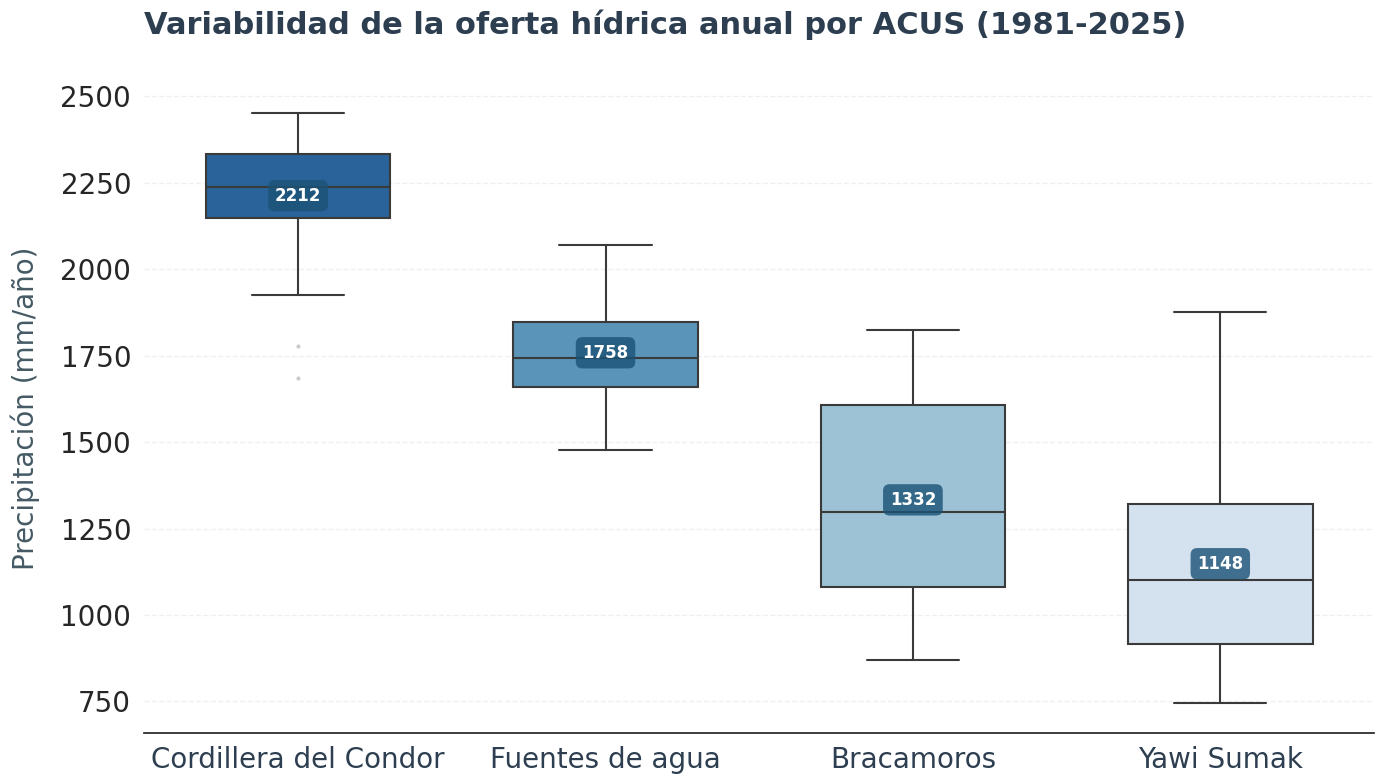

In [21]:
# --- 1. EXTRACCIÓN DE DATOS (GEE a Pandas) ---
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_precip_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reducción de región para obtener la lista de valores de píxeles
    dict_values = mean_annual_precip.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=5566,
        maxPixels=1e8
    ).getInfo()

    values_list = dict_values.get('precipitation')

    if values_list:
        df_temp = pd.DataFrame({'Precipitacion': values_list, 'ACUS': nombre})
        all_precip_data.append(df_temp)

df_boxplot_precip = pd.concat(all_precip_data, ignore_index=True)

# --- 2. DISEÑO DE LA VISUALIZACIÓN (Análisis Explicativo) ---

# Orden lógico: De mayor a menor mediana para facilitar la comparación
order = df_boxplot_precip.groupby('ACUS')['Precipitacion'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))
sns.set_style("white") # Fondo limpio para maximizar ratio datos-tinta

# Paleta azulada secuencial (Simboliza agua/precipitación)
colors = sns.color_palette("Blues_r", len(order))

ax = sns.boxplot(
    data=df_boxplot_precip,
    x='ACUS',
    y='Precipitacion',
    order=order,
    palette=colors,
    width=0.6,
    linewidth=1.5,
    fliersize=3,
    flierprops={"markerfacecolor": "0.5", "markeredgecolor": "none", "alpha": 0.4}
)

# --- 3. REFINAMIENTO Y JERARQUÍA VISUAL ---

# Título interpretativo (La "Gran Idea")
plt.title('Variabilidad de la oferta hídrica anual por ACUS (1981-2025)',
          fontsize=22, loc='left', pad=35, color='#2c3e50', fontweight='bold')

# Etiquetas de ejes (Grandes y legibles)
plt.xlabel('', fontsize=20)
plt.ylabel('Precipitación (mm/año)', fontsize=20, color='#455a64', labelpad=15)

# Eliminación de bordes innecesarios
sns.despine(left=True, bottom=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3) # Cuadrícula sutil solo horizontal

# Etiquetas del eje X horizontales (Evita carga cognitiva de rotación)
plt.xticks(fontsize=20, color='#2c3e50', rotation=0)
plt.yticks(fontsize=20)

# --- 4. ANOTACIÓN DE MEDIAS (Etiquetado Directo) ---
means = df_boxplot_precip.groupby('ACUS')['Precipitacion'].mean()
for i, name in enumerate(order):
    m = means[name]
    ax.text(
        i, m, f'{int(m)}',
        ha='center', va='center', fontsize=12,
        fontweight='bold', color='white',
        bbox=dict(facecolor='#1a5276', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4')
    )

plt.tight_layout()
plt.show()

### Monthly precipitation

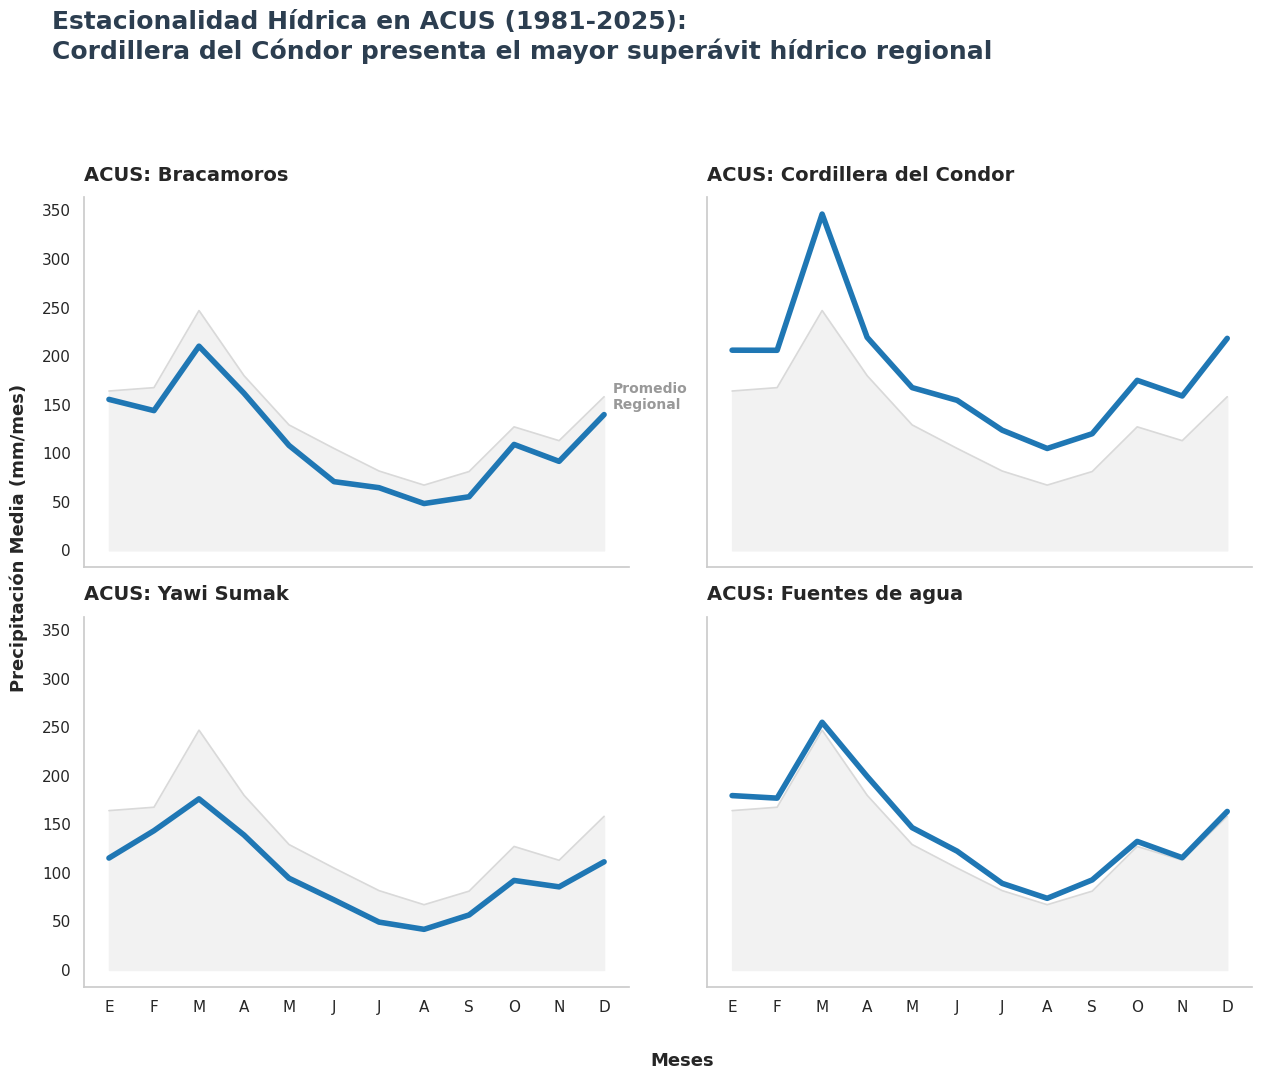

In [22]:
# Configuración de variables
start_year, end_year = 1981, 2025


chirps_filtered = chirps.filterDate(f'{start_year}-01-01', f'{end_year}-12-31')
months = ee.List.sequence(1, 12)

def get_monthly_mean(m):
    def get_annual_sum_for_month(y):
        return chirps_filtered.filter(ee.Filter.calendarRange(y, y, 'year')) \
                               .filter(ee.Filter.calendarRange(m, m, 'month')) \
                               .sum().set('month', m)
    annual_sums = ee.ImageCollection.fromImages(ee.List.sequence(start_year, end_year).map(get_annual_sum_for_month))
    return annual_sums.mean().set('month', m)

monthly_climatology = ee.ImageCollection.fromImages(months.map(get_monthly_mean))

# --- 2. FILTRAR Y MINAR (Extracción) ---
precip_monthly_data = []
# Se asume que 'nombres_categorias' y 'acus' están definidos en el entorno
for nombre in nombres_categorias[:4]: # Limitamos a 4 para el formato 2x2
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    def reduce_month(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=subset.geometry(), scale=5566, maxPixels=1e9)
        return ee.Feature(None, {'ACUS': nombre, 'Mes': img.get('month'), 'Precipitacion': stats.get('precipitation')})

    features = monthly_climatology.map(reduce_month).getInfo()['features']
    for f in features: precip_monthly_data.append(f['properties'])

df_monthly = pd.DataFrame(precip_monthly_data)
avg_regional = df_monthly.groupby('Mes')['Precipitacion'].mean()

# --- 3. REPRESENTAR Y REFINAR (Visualización para Informe) ---
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("white")

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
axes = axes.flatten()
month_names = ['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for i, nombre in enumerate(nombres_categorias[:4]):
    ax = axes[i]
    df_sub = df_monthly[df_monthly['ACUS'] == nombre]

    # 1. REFERENCIA: Promedio regional mejorado (Sombra)
    ax.fill_between(range(1, 13), avg_regional, color='#F2F2F2', alpha=1)
    ax.plot(range(1, 13), avg_regional, color='#D9D9D9', linewidth=1.2, linestyle='-')

    # 2. DATO PRINCIPAL: Línea de la ACUS resaltada
    ax.plot(range(1, 13), df_sub['Precipitacion'], color='#1f77b4', linewidth=4)

    # Etiquetas y Títulos con mayor tamaño (Legibilidad)
    ax.set_title(f"ACUS: {nombre}", fontsize=14, fontweight='bold', pad=12, loc='left')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # Etiquetado directo del promedio (solo en el primer cuadrante)
    if i == 0:
        ax.text(12.2, avg_regional.iloc[-1], 'Promedio\nRegional',
                color='#999999', fontsize=10, fontweight='bold', va='center')

    # Eliminar ruido (Ratio datos-tinta)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

# Título de Storytelling con Gran Idea
fig.suptitle('Estacionalidad Hídrica en ACUS (1981-2025):\nCordillera del Cóndor presenta el mayor superávit hídrico regional',
             fontsize=18, fontweight='bold', x=0.05, ha='left', color='#2C3E50')

# Etiquetas de ejes globales
fig.text(0.5, 0.02, 'Meses', ha='center', fontsize=13, fontweight='bold')
fig.text(0.02, 0.5, 'Precipitación Media (mm/mes)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0.03, 0.05, 0.92, 0.92])
plt.show()

### Time Series precipitation

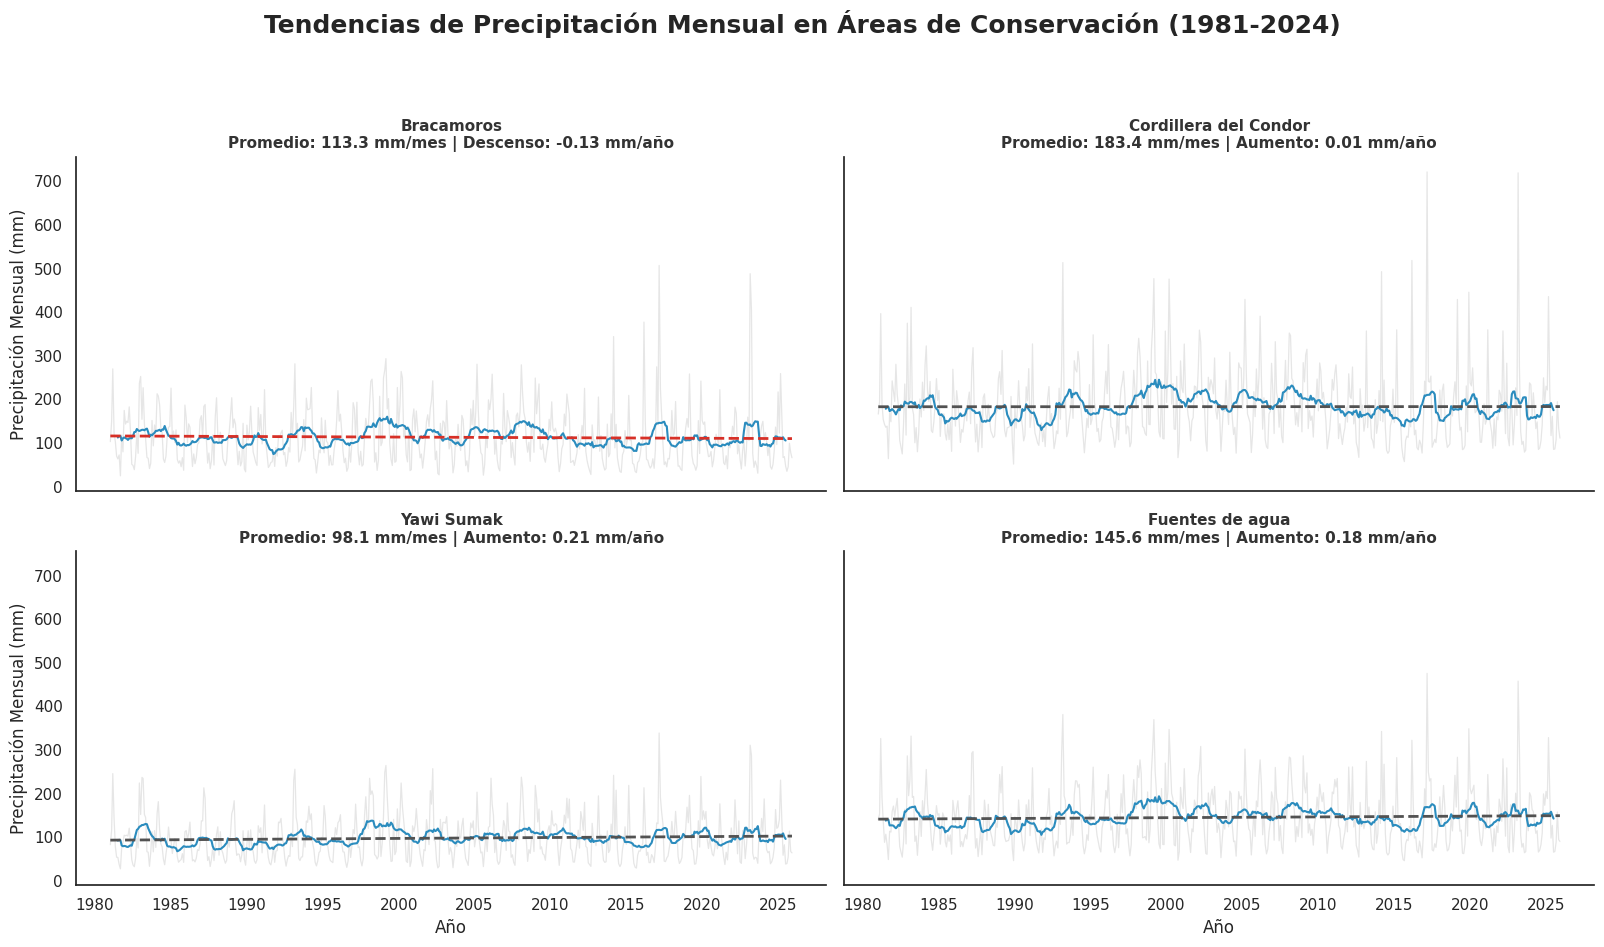

In [23]:
# --- 1. EXTRACCIÓN OPTIMIZADA (Google Earth Engine) ---
# Se recomienda usar esta lógica para evitar múltiples llamadas a getInfo()
start_year, end_year = 1981, 2025
years = ee.List.sequence(start_year, end_year)
months = ee.List.sequence(1, 12)

def get_monthly_images(y):
    return months.map(lambda m: chirps.filter(ee.Filter.calendarRange(y, y, 'year'))
                                     .filter(ee.Filter.calendarRange(m, m, 'month'))
                                     .sum()
                                     .set('year', y)
                                     .set('month', m)
                                     .set('system:time_start', ee.Date.fromYMD(y, m, 1).millis()))

monthly_chronology = ee.ImageCollection.fromImages(years.map(get_monthly_images).flatten())

all_features = []
for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    def reduce_region_ts(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=subset.geometry(),
            scale=5566,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'ACUS': nombre,
            'Time': img.get('system:time_start'),
            'Precipitacion': stats.get('precipitation')
        })

    # Procesamiento por sitio para mantener trazabilidad
    site_ts = monthly_chronology.map(reduce_region_ts).getInfo()['features']
    all_features.extend([f['properties'] for f in site_ts])

df_ts_full = pd.DataFrame(all_features)
df_ts_full['Fecha'] = pd.to_datetime(df_ts_full['Time'], unit='ms')

# --- 2. VISUALIZACIÓN REFINADA ---
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})
g = sns.FacetGrid(df_ts_full, col="ACUS", col_wrap=2, height=4.5, aspect=1.8, sharey=True)

def plot_refined_trend(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Fecha')

    # Datos mensuales (Ruido de fondo - 10% de énfasis)
    ax.plot(data['Fecha'], data['Precipitacion'], color='#E0E0E0', alpha=0.8, linewidth=0.9)

    # Media móvil de 12 meses (Ciclo anual)
    data['MA12'] = data['Precipitacion'].rolling(window=12, center=True).mean()
    ax.plot(data['Fecha'], data['MA12'], color='#2b8cbe', linewidth=1.5, label='Media Móvil 12m')

    # Tendencia Lineal
    x = np.arange(len(data))
    y = data['Precipitacion'].values
    # Manejo de NaNs para la regresión
    mask = ~np.isnan(y)
    slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(x[mask], y[mask])

    # Resaltado preatentivo: Si la tendencia es negativa, usar un rojo más intenso
    trend_color = '#d73027' if slope < 0 else '#525252'
    ax.plot(data['Fecha'], intercept + slope * x, color=trend_color, linestyle='--', linewidth=2)

    # Título interpretativo por faceta
    trend_label = "Descenso" if slope < 0 else "Aumento"
    ax.set_title(f"{data['ACUS'].iloc[0]}\nPromedio: {data['Precipitacion'].mean():.1f} mm/mes | {trend_label}: {slope*12:.2f} mm/año",
                 fontweight='bold', fontsize=11, color='#333333')

g.map_dataframe(plot_refined_trend)
g.set_axis_labels("Año", "Precipitación Mensual (mm)")

# Título de la Gran Idea
g.fig.suptitle('Tendencias de Precipitación Mensual en Áreas de Conservación (1981-2024)',
               fontsize=18, fontweight='bold', y=1.05, color='#252525')

plt.tight_layout()
plt.show()

### Mann Kendall - raster

In [24]:

# Definir periodo de análisis
start_year = 1981
end_year = 2025 # Nota: Verificar disponibilidad completa de 2025 según fecha actual
years = ee.List.sequence(start_year, end_year)

# 1. Agregación de precipitación anual
def aggregate_annual(year):
    year_num = ee.Number(year)
    annual_precip = chirps \
        .filter(ee.Filter.calendarRange(year_num, year_num, 'year')) \
        .sum() \
        .set('year', year_num) \
        .set('system:time_start', ee.Date.fromYMD(year_num, 1, 1).millis())
    return annual_precip

annual_collection = ee.ImageCollection.fromImages(years.map(aggregate_annual))

# 2. Preparar bandas para el análisis (X: Tiempo, Y: Precipitación)
def add_time_band(img):
    year = ee.Image.constant(ee.Number(img.get('year'))).rename('time').toDouble()
    return img.addBands(year)

trend_prep = annual_collection.map(add_time_band)

# 3. Cálculo de Mann-Kendall (Significancia y Tau)
mk_stats = trend_prep.select(['time', 'precipitation']).reduce(ee.Reducer.kendallsCorrelation())
tau = mk_stats.select('precipitation_tau')
p_value = mk_stats.select('precipitation_p-value')

# 4. Cálculo de Sen's Slope (Magnitud)
sens_stats = trend_prep.select(['time', 'precipitation']).reduce(ee.Reducer.sensSlope())
slope = sens_stats.select('slope')

# 5. Filtrado por significancia estadística (Alpha = 0.05)
significant_mask = p_value.lt(0.05)
significant_slope = slope.updateMask(significant_mask).clip(aoi)

# --- MENSAJE DE RESULTADOS ---
sig_area = significant_slope.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi.geometry(),
    scale=5566,
    maxPixels=1e9
).get('slope').getInfo()

if sig_area == 0 or sig_area is None:
    print("RESULTADO DEL ANÁLISIS: No se detectaron tendencias estadísticamente significativas (p < 0.05) en el área de estudio.")
    print("La estabilidad climática predomina en el periodo 1981-2025.")
else:
    print(f"RESULTADO DEL ANÁLISIS: Se detectaron áreas con tendencias significativas. Conteo de píxeles significativos: {sig_area}")

# Configuración del mapa
map_analysis = geemap.Map()
map_analysis.centerObject(aoi, 9)

vis_tau = {'min': -1, 'max': 1, 'palette': ['#d73027', '#f7f7f7', '#1a9850']}
vis_p = {'min': 0, 'max': 0.1, 'palette': ['#000000', '#ffffff']}
vis_params_slope = {
    'min': -20,
    'max': 20,
    'palette': ['#8c510a', '#d8b365', '#f6e8c3', '#c7eae5', '#5ab4ac', '#01665e']
}

map_analysis.addLayer(tau.clip(aoi), vis_tau, 'Fuerza de Tendencia (Kendall Tau)')
map_analysis.addLayer(p_value.clip(aoi), vis_p, 'Significancia (P-Value)')
map_analysis.addLayer(slope.clip(aoi), vis_params_slope, 'Pendiente de Sen (Total)')
map_analysis.addLayer(significant_slope, vis_params_slope, 'Pendiente de Sen (Significativa)')
map_analysis.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

map_analysis.add_colorbar(vis_params_slope, label="Cambio de Precipitación (mm/año)")

#display(map_analysis)


RESULTADO DEL ANÁLISIS: No se detectaron tendencias estadísticamente significativas (p < 0.05) en el área de estudio.
La estabilidad climática predomina en el periodo 1981-2025.


Inside ACUS

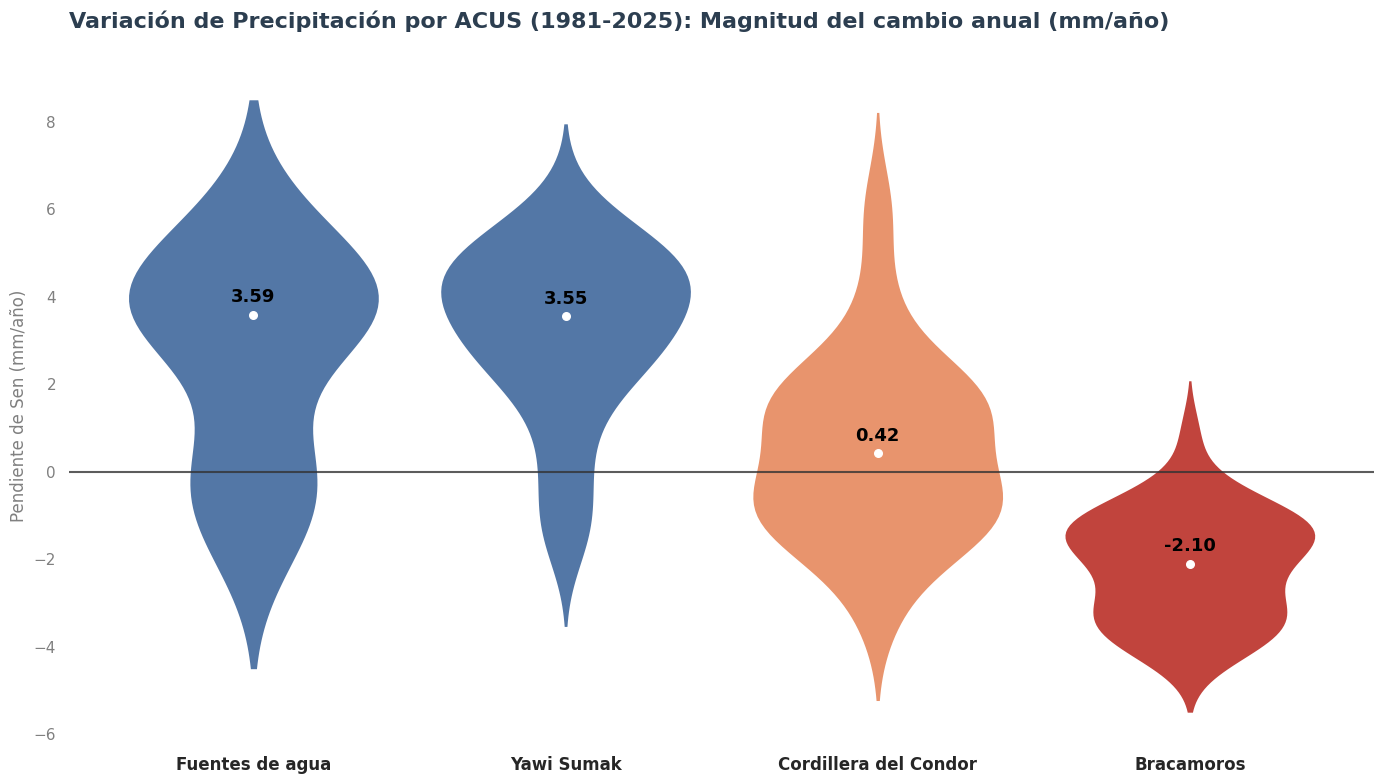

In [25]:
# 1. EXTRACCIÓN DE DATOS DE SEN'S SLOPE POR ACUS
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_sens_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    values_list = slope.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=5566,
        maxPixels=1e8
    ).get('slope').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'Sen_Slope': values_list, 'ACUS': nombre})
        all_sens_data.append(df_temp)

df_sens = pd.concat(all_sens_data, ignore_index=True)

# 2. VISUALIZACIÓN OPTIMIZADA (RATIO DATOS-TINTA)
if not df_sens.empty:
    plt.figure(figsize=(14, 8))
    sns.set_theme(style='white') # Fondo limpio sin cuadrícula

    # Ordenar por mediana
    order = df_sens.groupby('ACUS')['Sen_Slope'].median().sort_values(ascending=False).index
    medians = df_sens.groupby('ACUS')['Sen_Slope'].median()

    # Invertir colores: Azul para incrementos positivos, Naranja/Rojo para descensos
    colors = ['#4575b4' if medians[name] > 2 else '#fc8d59' if medians[name] > 0 else '#d73027' for name in order]

    # Crear el gráfico de violín sin contornos y solo mediana
    ax = sns.violinplot(data=df_sens, x='ACUS', y='Sen_Slope', order=order,
                        palette=colors, inner=None, linewidth=0)

    # 3. ETIQUETADO DIRECTO Y RESALTADO
    for i, name in enumerate(order):
        median_val = medians[name]
        # Punto blanco para la mediana
        ax.scatter(i, median_val, color='white', s=30, zorder=3)
        # Etiqueta con mayor peso visual
        ax.text(i, median_val + 0.2, f'{median_val:.2f}',
                ha='center', va='bottom', fontsize=13, fontweight='black',
                color='black')

    # Refinamiento estético y Título simplificado
    plt.title('Variación de Precipitación por ACUS (1981-2025): Magnitud del cambio anual (mm/año)',
              fontsize=16, fontweight='bold', pad=30, loc='left', color='#2c3e50')

    plt.ylabel('Pendiente de Sen (mm/año)', fontsize=12, color='gray')
    plt.xlabel('', fontsize=12)

    # Solo mantener la línea del cero y remover espinas
    plt.axhline(0, color='#333333', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)
    sns.despine(left=True, bottom=True)

    # Limpiar la estética de los ejes
    plt.tick_params(axis='y', colors='gray')
    plt.xticks(fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Aviso: No se pudieron extraer datos de la pendiente de Sen para las ACUS.')

### Consecutive Dry Days

Extrayendo series de tiempo de CDD para cada ACUS. Esto puede tomar un momento...


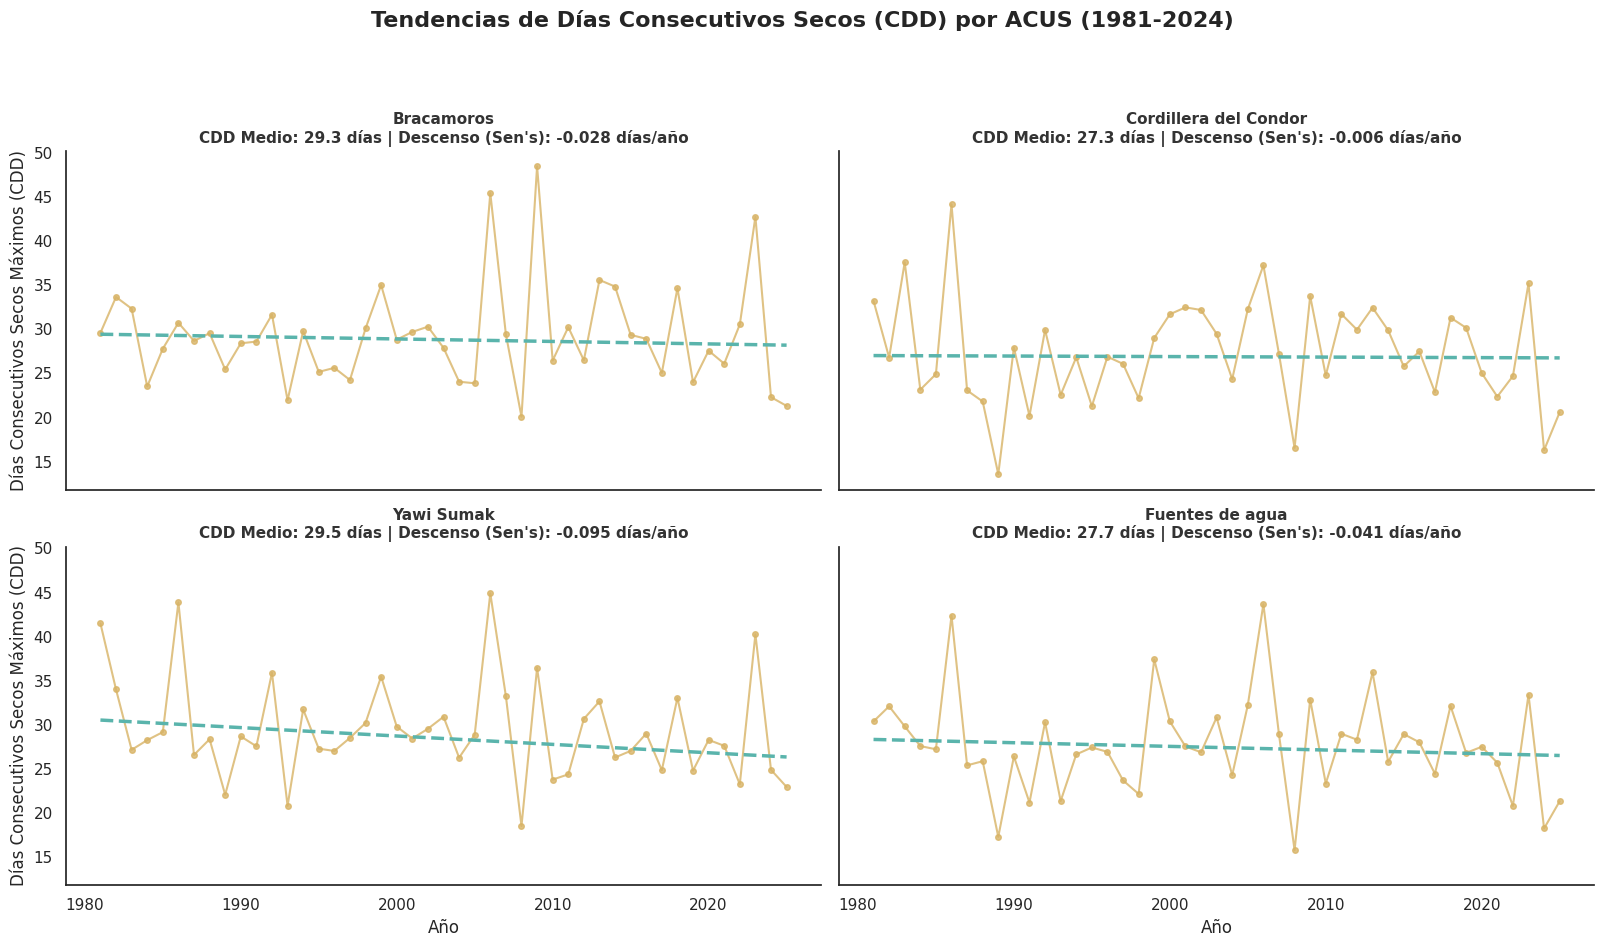

In [26]:
# --- CÁLCULO DE DÍAS CONSECUTIVOS SECOS (CDD) POR ACUS Y SERIE DE TIEMPO ---
import scipy.stats

# 1. Parámetros de tiempo
years_list = ee.List.sequence(1981, 2025)

def calculate_annual_cdd(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    # Colección diaria filtrada: 1 si es seco (<1mm), 0 si es húmedo
    daily_dry_mask = chirps.filterDate(start, end).map(lambda img: img.lt(1).rename('is_dry'))

    # Algoritmo de acumulación de días consecutivos
    def accumulate_dry(img, prev):
        prev_img = ee.Image(prev)
        accum = prev_img.select('accum')
        max_cdd = prev_img.select('max_cdd')

        # Si hoy es seco (1), suma 1 al acumulador. Si es húmedo (0), lo vuelve 0.
        current_accum = accum.add(img).multiply(img).rename('accum')
        # El nuevo máximo
        new_max = max_cdd.max(current_accum).rename('max_cdd')
        return current_accum.addBands(new_max)

    # Inicializar con dos bandas en cero
    initial = ee.Image.constant(0).rename('accum').addBands(ee.Image.constant(0).rename('max_cdd'))
    cdd_final = ee.Image(daily_dry_mask.iterate(accumulate_dry, initial)).toInt16()

    return cdd_final.select('max_cdd').set('year', year).set('system:time_start', start.millis())

# Generar colección de CDD anual
cdd_collection = ee.ImageCollection.fromImages(years_list.map(calculate_annual_cdd))

# 2. Extracción de datos por ACUS (Promedio espacial del máximo anual)
print("Extrayendo series de tiempo de CDD para cada ACUS. Esto puede tomar un momento...")
all_cdd_features = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    def reduce_cdd(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=subset.geometry(),
            scale=5566,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'ACUS': nombre,
            'Year': img.get('year'),
            'CDD': stats.get('max_cdd')
        })

    site_cdd = cdd_collection.map(reduce_cdd).getInfo()['features']
    all_cdd_features.extend([f['properties'] for f in site_cdd])

df_cdd_ts = pd.DataFrame(all_cdd_features)

# 3. Visualización y cálculo de Sen's Slope en Python
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})
g = sns.FacetGrid(df_cdd_ts, col="ACUS", col_wrap=2, height=4.5, aspect=1.8, sharey=True)

def plot_cdd_trend(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Year')

    # Serie de tiempo anual
    ax.plot(data['Year'], data['CDD'], color='#d8b365', alpha=0.8, linewidth=1.5, marker='o', markersize=4)

    # Cálculo de Sen's Slope (Theil-Sen estimator)
    x = data['Year'].values
    y = data['CDD'].values
    mask = ~np.isnan(y)

    # theilslopes devuelve: slope, intercept, lower_bound, upper_bound
    res = scipy.stats.theilslopes(y[mask], x[mask], 0.95)
    slope = res[0]
    intercept = res[1]

    # Tendencia (Rojo si aumentan los días secos, verde/azul si disminuyen)
    trend_color = '#d73027' if slope > 0 else '#5ab4ac'
    ax.plot(data['Year'], intercept + slope * x, color=trend_color, linestyle='--', linewidth=2.5)

    trend_label = "Aumento" if slope > 0 else "Descenso"
    ax.set_title(f"{data['ACUS'].iloc[0]}\nCDD Medio: {data['CDD'].mean():.1f} días | {trend_label} (Sen's): {slope:.3f} días/año",
                 fontweight='bold', fontsize=11, color='#333333')

g.map_dataframe(plot_cdd_trend)
g.set_axis_labels("Año", "Días Consecutivos Secos Máximos (CDD)")

g.fig.suptitle('Tendencias de Días Consecutivos Secos (CDD) por ACUS (1981-2024)',
               fontsize=16, fontweight='bold', y=1.05, color='#252525')

plt.tight_layout()
plt.show()


### Consecutive Wet Days

Extrayendo series de tiempo de CWD para cada ACUS. Esto puede tomar un momento...


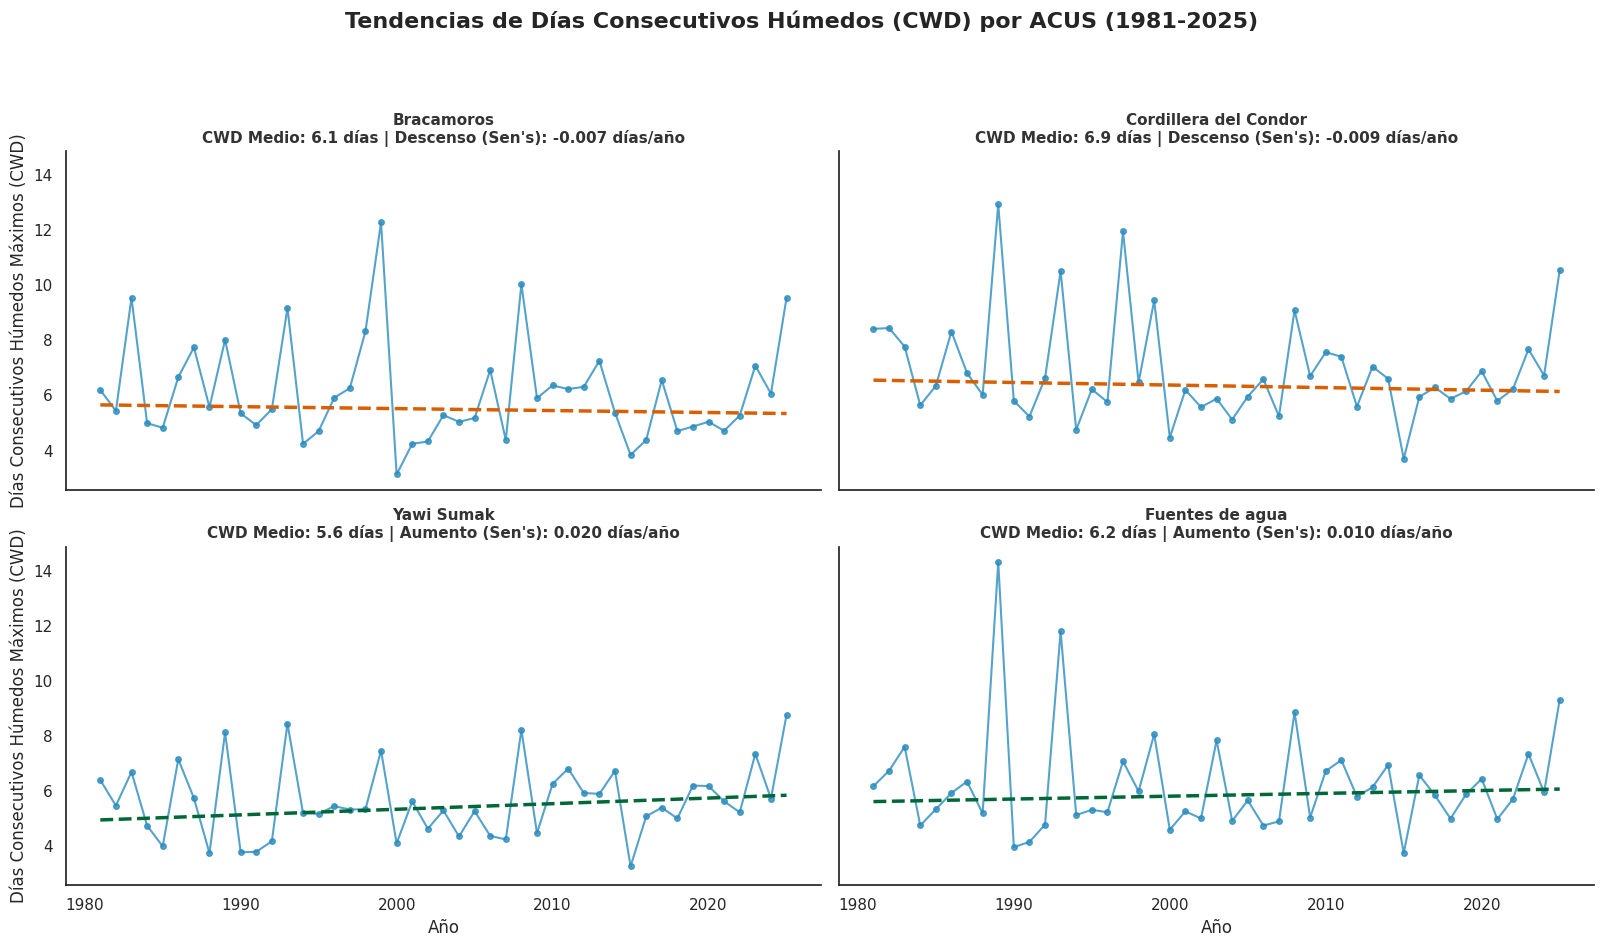

In [27]:

# 1. Parámetros de tiempo
years_list = ee.List.sequence(1981, 2025)

def calculate_annual_cwd(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    # Colección diaria filtrada: 1 si es húmedo (>=1mm), 0 si es seco
    daily_wet_mask = chirps.filterDate(start, end).map(lambda img: img.gte(1).rename('is_wet'))

    # Algoritmo de acumulación de días consecutivos
    def accumulate_wet(img, prev):
        prev_img = ee.Image(prev)
        accum = prev_img.select('accum')
        max_cwd = prev_img.select('max_cwd')

        # Si hoy es húmedo (1), suma 1 al acumulador. Si es seco (0), lo vuelve 0.
        current_accum = accum.add(img).multiply(img).rename('accum')
        # El nuevo máximo
        new_max = max_cwd.max(current_accum).rename('max_cwd')
        return current_accum.addBands(new_max)

    # Inicializar con dos bandas en cero
    initial = ee.Image.constant(0).rename('accum').addBands(ee.Image.constant(0).rename('max_cwd'))
    cwd_final = ee.Image(daily_wet_mask.iterate(accumulate_wet, initial)).toInt16()

    return cwd_final.select('max_cwd').set('year', year).set('system:time_start', start.millis())

# Generar colección de CWD anual
cwd_collection = ee.ImageCollection.fromImages(years_list.map(calculate_annual_cwd))

# 2. Extracción de datos por ACUS (Promedio espacial del máximo anual)
print("Extrayendo series de tiempo de CWD para cada ACUS. Esto puede tomar un momento...")
all_cwd_features = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    def reduce_cwd(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=subset.geometry(),
            scale=5566,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'ACUS': nombre,
            'Year': img.get('year'),
            'CWD': stats.get('max_cwd')
        })

    site_cwd = cwd_collection.map(reduce_cwd).getInfo()['features']
    all_cwd_features.extend([f['properties'] for f in site_cwd])

df_cwd_ts = pd.DataFrame(all_cwd_features)

# 3. Visualización y cálculo de Sen's Slope en Python
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})
g = sns.FacetGrid(df_cwd_ts, col="ACUS", col_wrap=2, height=4.5, aspect=1.8, sharey=True)

def plot_cwd_trend(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Year')

    # Serie de tiempo anual (Azul para indicar humedad)
    ax.plot(data['Year'], data['CWD'], color='#2b8cbe', alpha=0.8, linewidth=1.5, marker='o', markersize=4)

    # Cálculo de Sen's Slope (Theil-Sen estimator)
    x = data['Year'].values
    y = data['CWD'].values
    mask = ~np.isnan(y)

    # theilslopes devuelve: slope, intercept, lower_bound, upper_bound
    res = scipy.stats.theilslopes(y[mask], x[mask], 0.95)
    slope = res[0]
    intercept = res[1]

    # Tendencia (Verde oscuro si aumentan los días húmedos, naranja oscuro si disminuyen)
    trend_color = '#006837' if slope > 0 else '#d95f02'
    ax.plot(data['Year'], intercept + slope * x, color=trend_color, linestyle='--', linewidth=2.5)

    trend_label = "Aumento" if slope > 0 else "Descenso"
    ax.set_title(f"{data['ACUS'].iloc[0]}\nCWD Medio: {data['CWD'].mean():.1f} días | {trend_label} (Sen's): {slope:.3f} días/año",
                 fontweight='bold', fontsize=11, color='#333333')

g.map_dataframe(plot_cwd_trend)
g.set_axis_labels("Año", "Días Consecutivos Húmedos Máximos (CWD)")

g.fig.suptitle('Tendencias de Días Consecutivos Húmedos (CWD) por ACUS (1981-2025)',
               fontsize=16, fontweight='bold', y=1.05, color='#252525')

plt.tight_layout()
plt.show()


### $R$ (Rainfall erosivity factor)

In [28]:
# --- CÁLCULO DEL FACTOR DE EROSIVIDAD R (RUSLE) ---
# Basado en la fórmula: R = 587.8 - 1.219P + 0.004105P^2

# 1. Cargar el dataset de OpenLandMap (Precipitación mensual SM2RAIN)
precip_monthly = ee.Image("OpenLandMap/CLM/CLM_PRECIPITATION_SM2RAIN_M/v01")

# 2. Calcular la Precipitación Anual Total (P)
annual_p = precip_monthly.reduce(ee.Reducer.sum()).rename('P')

# 3. Cálculo del Factor R usando la nueva fórmula
# R = 587.8 - 1.219*P + 0.004105*P^2
term1 = ee.Image.constant(587.8)
term2 = annual_p.multiply(-1.219)
term3 = annual_p.pow(2).multiply(0.004105)

r_factor = term1.add(term2).add(term3).rename('R_Factor').clip(aoi)

# 4. Visualización del resultado
map_r = geemap.Map(data_ctrl=False)
map_r.centerObject(aoi, 9)

# Parámetros de visualización para R
r_vis = {
    'min': 4000,
    'max': 30000,
    'palette': ['#ffffb2', '#fed976', '#feb24c', '#fd8d3c', '#f03b20', '#bd0026']
}

map_r.addLayer(r_factor, r_vis, 'Factor de Erosividad R (Nueva Fórmula)')
map_r.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')
map_r.add_colorbar(r_vis, label="Factor R (MJ.mm/ha.h.año)")

# Imprimir estadísticas básicas para verificación
stats_r = r_factor.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.min(), '', True).combine(ee.Reducer.max(), '', True),
    geometry=aoi.geometry(),
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f"Factor R Medio en el AOI: {stats_r.get('R_Factor_mean'):.2f}")
print(f"Factor R Mínimo: {stats_r.get('R_Factor_min'):.2f}")
print(f"Factor R Máximo: {stats_r.get('R_Factor_max'):.2f}")

#map_r

Factor R Medio en el AOI: 9751.86
Factor R Mínimo: 4036.45
Factor R Máximo: 31575.75


Inside ACUS

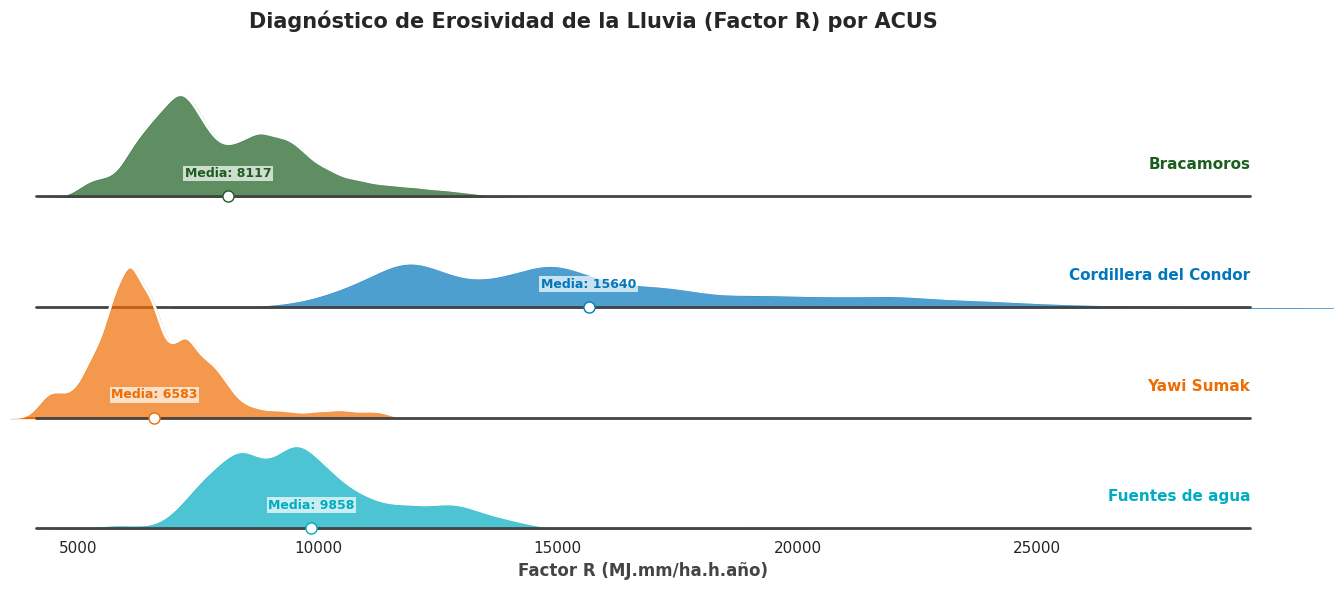

In [29]:
# --- VISUALIZACIÓN DEL FACTOR R POR ACUS (RIDGELINE PLOT) ---

# 1. Extracción de datos (Ya realizado en df_r_plot)
# Aseguramos que los datos estén cargados si se ejecuta de nuevo la celda
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_r_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    dict_values = r_factor.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=1000,
        maxPixels=1e8
    ).getInfo()

    values_list = dict_values.get('R_Factor')
    if values_list:
        df_temp = pd.DataFrame({'R_Factor': values_list, 'ACUS': nombre})
        all_r_data.append(df_temp)

df_r_plot = pd.concat(all_r_data, ignore_index=True)

# 2. Configuración estética del Ridgeline Plot
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

# Crear el FacetGrid usando la paleta personalizada
g = sns.FacetGrid(df_r_plot, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

# Mapear las densidades (KDE)
g.map(sns.kdeplot, "R_Factor", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "R_Factor", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. Función de etiquetado para las ACUS y estadísticas (Nombres a la derecha)
def annotate_r_factor(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS a la derecha
    ax.text(1, 0.2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media
    ax.text(curr_mean, 0.00005, f'Media: {int(curr_mean)}', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_r_factor, "R_Factor")

# 4. Refinamiento final
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(df_r_plot['R_Factor'].min(), df_r_plot['R_Factor'].max()))
g.despine(bottom=True, left=True)

plt.xlabel("Factor R (MJ.mm/ha.h.año)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Diagnóstico de Erosividad de la Lluvia (Factor R) por ACUS',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

## 4.3. MODIS: Surface Temperature

### Median: 2025

In [48]:
# 1. Filtrar solo para el año 2025 y calcular la mediana
lst_2025 = modis_lst.filterDate('2025-01-01', '2025-12-31')
lst_median = lst_2025.select('LST_Day_1km').median()

# 2. Convertir a Celsius
lst_celsius = lst_median.multiply(0.02).subtract(273.15).clip(aoi)

# 3. Obtener estadísticas para visualización (escala 1000m)
stats = lst_celsius.reduceRegion(
    reducer=ee.Reducer.percentile([2, 98]),
    geometry=aoi.geometry(),
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f"Estadísticas LST 2025: {stats}")

# 4. Visualización
lst_vis = {
    'min': 12,
    'max': 28,
    'palette': ['#0000ff', '#00ffff', '#ffff00', '#ff0000', '#7f0000']
}

map_lst = geemap.Map(data_ctrl=False)
map_lst.centerObject(aoi, 9)
map_lst.addLayer(lst_celsius, lst_vis, 'LST Media 2025 (°C)')
map_lst.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')
map_lst.add_colorbar(lst_vis, label="LST Diurna 2025 (°C)")
map_lst

Estadísticas LST 2025: {'LST_Day_1km_p2': 11.44190190651909, 'LST_Day_1km_p98': 23.436914591054084}


Map(center=[-4.170786346022255, -78.90378780278301], controls=(WidgetControl(options=['position', 'transparent…

Inside ACUS

Extrayendo datos de LST para el gráfico...


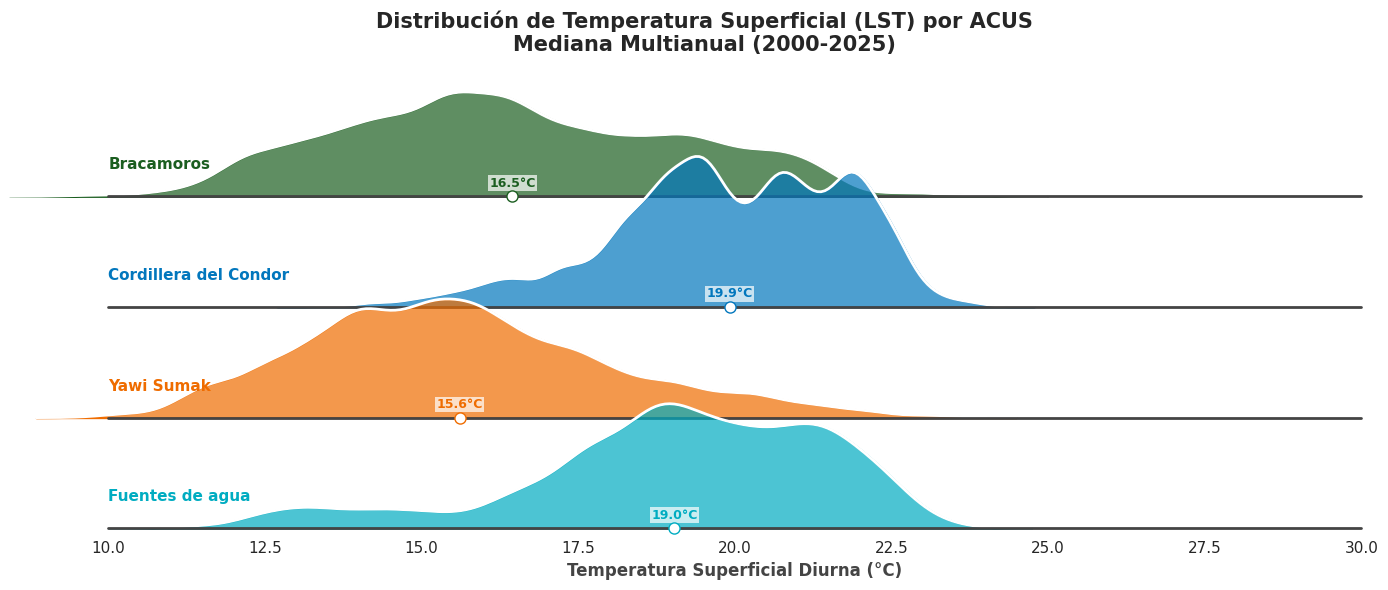

In [49]:
# 1. EXTRACCIÓN DE DATOS DE LST (Google Earth Engine)
# Usamos la mediana de LST diurna en Celsius (lst_celsius) calculada previamente
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_lst_data = []

print("Extrayendo datos de LST para el gráfico...")
for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    # Extraer valores de píxeles (escala 1km para MODIS LST)
    values_list = lst_celsius.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=1000,
        maxPixels=1e8
    ).get('LST_Day_1km').getInfo()

    if values_list and len(values_list) > 0:
        df_temp = pd.DataFrame({'LST': values_list, 'ACUS': nombre})
        all_lst_data.append(df_temp)

if len(all_lst_data) > 0:
    df_plot_lst = pd.concat(all_lst_data, ignore_index=True)

    # 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

    g = sns.FacetGrid(df_plot_lst, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

    # Mapeo de densidades (KDE)
    g.map(sns.kdeplot, "LST", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
    g.map(sns.kdeplot, "LST", clip_on=False, color="white", lw=2, bw_adjust=.6)
    g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

    # 3. FUNCIÓN DE ETIQUETADO
    def annotate_lst(x, color, label):
        ax = plt.gca()
        curr_mean = x.mean()
        ax.text(0, 0.2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes, fontsize=11)
        ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
                markersize=8, zorder=10, clip_on=False)
        ax.text(curr_mean, 0.01, f'{curr_mean:.1f}°C', color=color, fontweight='bold',
                ha="center", va="bottom", fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    g.map(annotate_lst, "LST")

    # 4. REFINAMIENTO
    g.fig.subplots_adjust(hspace=-.3)
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlim=(10, 30))
    g.despine(bottom=True, left=True)

    plt.xlabel("Temperatura Superficial Diurna (°C)", fontsize=12, fontweight='bold', color='#444444')
    plt.suptitle('Distribución de Temperatura Superficial (LST) por ACUS\nMediana Multianual (2000-2025)',
                 fontsize=15, fontweight='bold', y=0.98)
    plt.show()
else:
    print("No se encontraron datos para generar el gráfico de LST.")

In [50]:
# Calcular estadísticas principales de LST para cada ACUS
lst_stats_list = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor combinado para media, min, max y desv. estándar
    reducers = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), '', True) \
        .combine(ee.Reducer.min(), '', True) \
        .combine(ee.Reducer.max(), '', True)

    stats = lst_celsius.reduceRegion(
        reducer=reducers,
        geometry=subset.geometry(),
        scale=1000,
        maxPixels=1e8
    ).getInfo()

    if stats:
        lst_stats_list.append({
            'ACUS': nombre,
            'LST Mínima (°C)': round(stats.get('LST_Day_1km_min'), 2) if stats.get('LST_Day_1km_min') else None,
            'LST Máxima (°C)': round(stats.get('LST_Day_1km_max'), 2) if stats.get('LST_Day_1km_max') else None,
            'LST Media (°C)': round(stats.get('LST_Day_1km_mean'), 2) if stats.get('LST_Day_1km_mean') else None,
            'Desv. Estándar (°C)': round(stats.get('LST_Day_1km_stdDev'), 2) if stats.get('LST_Day_1km_stdDev') else None
        })

# Crear DataFrame y mostrar tabla
df_stats_lst = pd.DataFrame(lst_stats_list)

# Estilizar la tabla
print("Resumen Estadístico de Temperatura Superficial (LST) por ACUS")
display(df_stats_lst.style.background_gradient(subset=['LST Media (°C)'], cmap='YlOrRd').format(precision=2))


Resumen Estadístico de Temperatura Superficial (LST) por ACUS


,ACUS,LST Mínima (°C),LST Máxima (°C),LST Media (°C),Desv. Estándar (°C)
0,Bracamoros,8.61,23.88,16.45,2.94
1,Cordillera del Condor,13.47,24.00,19.94,1.84
2,Yawi Sumak,9.87,23.47,15.63,2.67
3,Fuentes de agua,11.29,24.09,19.09,2.40


### Monthly temperature

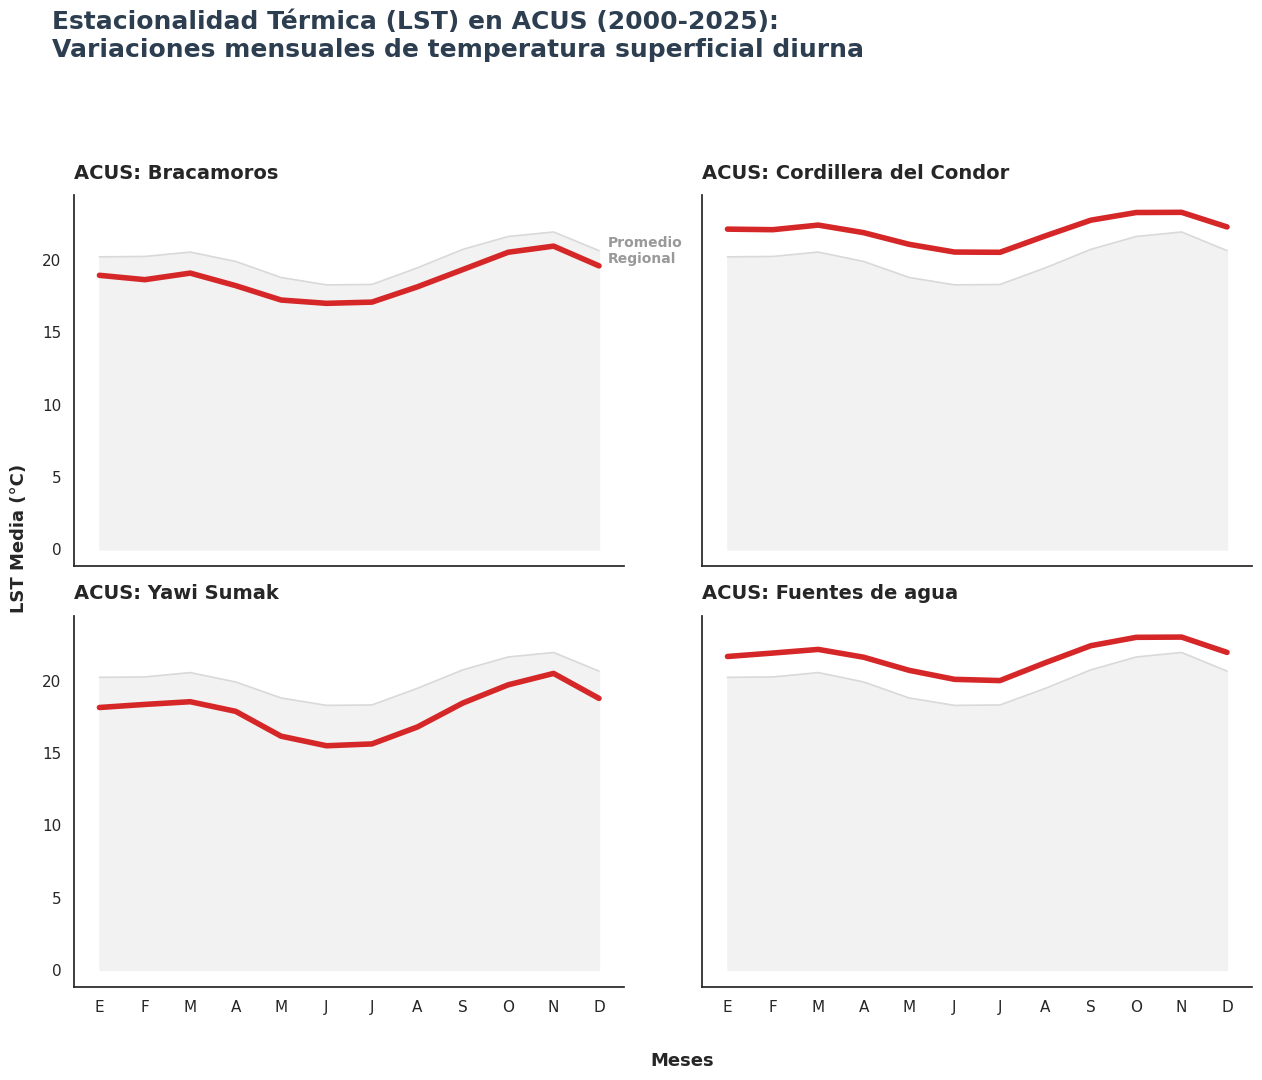

In [51]:
# 1. CONFIGURACIÓN Y CÁLCULO DE CLIMATOLOGÍA MENSUAL (LST)
start_year, end_year = 2000, 2025
months = ee.List.sequence(1, 12)

def get_monthly_lst_mean(m):
    # Filtrar por mes y calcular la media de todos los años disponibles
    monthly_coll = modis_lst.filter(ee.Filter.calendarRange(m, m, 'month'))
    # Convertir a Celsius: (DN * 0.02) - 273.15
    img_celsius = monthly_coll.select('LST_Day_1km').mean().multiply(0.02).subtract(273.15)
    return img_celsius.set('month', m)

lst_climatology = ee.ImageCollection.fromImages(months.map(get_monthly_lst_mean))

# 2. EXTRACCIÓN DE DATOS POR ACUS
lst_monthly_data = []
for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    def reduce_lst_month(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=subset.geometry(), scale=1000, maxPixels=1e9)
        return ee.Feature(None, {'ACUS': nombre, 'Mes': img.get('month'), 'LST': stats.get('LST_Day_1km')})

    features = lst_climatology.map(reduce_lst_month).getInfo()['features']
    for f in features: lst_monthly_data.append(f['properties'])

df_lst_monthly = pd.DataFrame(lst_monthly_data)
avg_regional_lst = df_lst_monthly.groupby('Mes')['LST'].mean()

# 3. VISUALIZACIÓN
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
axes = axes.flatten()
month_names = ['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for i, nombre in enumerate(nombres_categorias[:4]):
    ax = axes[i]
    df_sub = df_lst_monthly[df_lst_monthly['ACUS'] == nombre]

    # Referencia Regional
    ax.fill_between(range(1, 13), avg_regional_lst, color='#F2F2F2', alpha=1)
    ax.plot(range(1, 13), avg_regional_lst, color='#D9D9D9', linewidth=1.2, linestyle='-')

    # Dato Principal (LST)
    ax.plot(range(1, 13), df_sub['LST'], color='#d62728', linewidth=4)

    ax.set_title(f"ACUS: {nombre}", fontsize=14, fontweight='bold', pad=12, loc='left')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=11)

    if i == 0:
        ax.text(12.2, avg_regional_lst.iloc[-1], 'Promedio\nRegional', color='#999999', fontsize=10, fontweight='bold', va='center')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Estacionalidad Térmica (LST) en ACUS (2000-2025):\nVariaciones mensuales de temperatura superficial diurna', fontsize=18, fontweight='bold', x=0.05, ha='left', color='#2C3E50')
fig.text(0.5, 0.02, 'Meses', ha='center', fontsize=13, fontweight='bold')
fig.text(0.02, 0.5, 'LST Media (°C)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0.03, 0.05, 0.92, 0.92])
plt.show()

### Time series

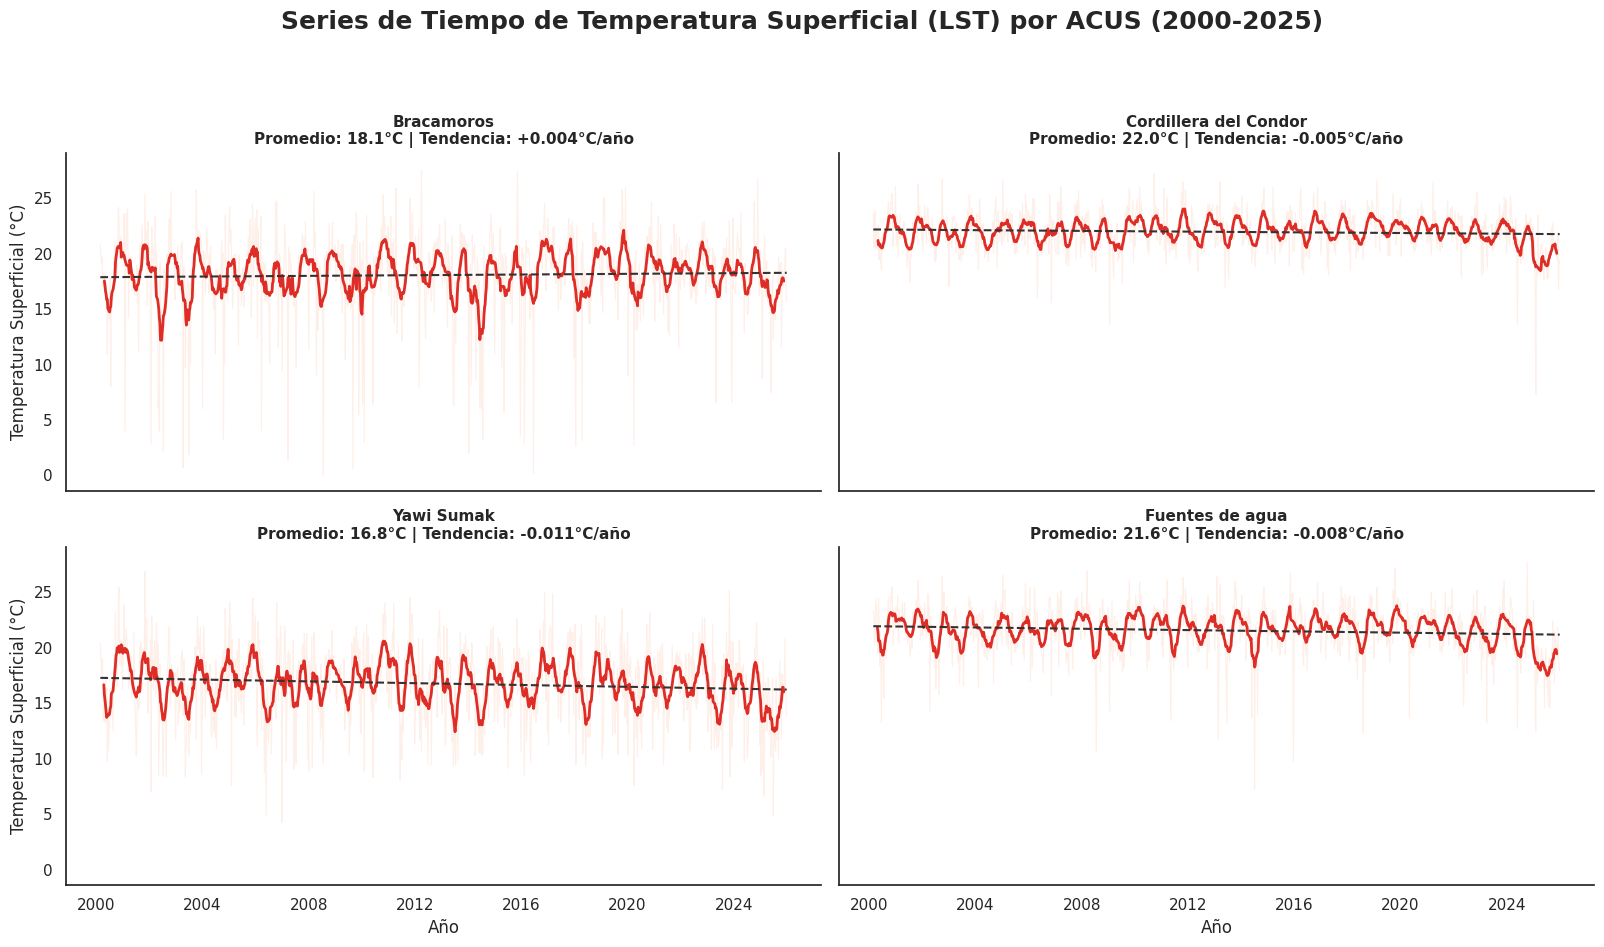

In [52]:
# --- 1. PROCESAMIENTO DE SERIE DE TIEMPO MENSUAL (LST) ---
# Usamos la colección modis_lst filtrada anteriormente

all_lst_ts = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    def reduce_lst_ts(img):
        # Convertir a Celsius: (DN * 0.02) - 273.15
        temp_c = img.select('LST_Day_1km').multiply(0.02).subtract(273.15)
        stats = temp_c.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=subset.geometry(),
            scale=1000,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'ACUS': nombre,
            'Time': img.get('system:time_start'),
            'LST': stats.get('LST_Day_1km')
        })

    # Extraer datos mensuales
    site_ts = modis_lst.map(reduce_lst_ts).getInfo()['features']
    all_lst_ts.extend([f['properties'] for f in site_ts])

df_lst_ts = pd.DataFrame(all_lst_ts)
df_lst_ts['Fecha'] = pd.to_datetime(df_lst_ts['Time'], unit='ms')

# --- 2. VISUALIZACIÓN CON LÍNEA DE TENDENCIA ---
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})
g = sns.FacetGrid(df_lst_ts, col="ACUS", col_wrap=2, height=4.5, aspect=1.8, sharey=True)

def plot_lst_trend(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Fecha').dropna(subset=['LST'])

    # 1. Datos Mensuales (Sutiles)
    ax.plot(data['Fecha'], data['LST'], color='#fee0d2', alpha=0.5, linewidth=0.8)

    # 2. Media Móvil (12 meses para eliminar estacionalidad)
    data['MA12'] = data['LST'].rolling(window=12, center=True).mean()
    ax.plot(data['Fecha'], data['MA12'], color='#de2d26', linewidth=2, label='Media Móvil 12m')

    # 3. Línea de Tendencia (Regresión Lineal)
    x_numeric = np.arange(len(data))
    y = data['LST'].values
    slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(x_numeric, y)

    ax.plot(data['Fecha'], intercept + slope * x_numeric, color='#333333', linestyle='--', linewidth=1.5)

    # Título con metadatos de tendencia
    trend_sign = "+" if slope > 0 else "-"
    ax.set_title(f"{data['ACUS'].iloc[0]}\nPromedio: {data['LST'].mean():.1f}°C | Tendencia: {trend_sign}{abs(slope*12):.3f}°C/año",
                 fontweight='bold', fontsize=11)

g.map_dataframe(plot_lst_trend)
g.set_axis_labels("Año", "Temperatura Superficial (°C)")

g.fig.suptitle('Series de Tiempo de Temperatura Superficial (LST) por ACUS (2000-2025)',
               fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

### Mann Kendall

In [55]:

# 1. Agregación de LST anual (Mediana para reducir ruido de nubes)
def aggregate_lst_annual(year):
    year_num = ee.Number(year)
    annual_median = modis_lst.filter(ee.Filter.calendarRange(year_num, year_num, 'year')) \
        .select('LST_Day_1km') \
        .median() \
        .multiply(0.02).subtract(273.15) \
        .set('year', year_num) \
        .set('system:time_start', ee.Date.fromYMD(year_num, 1, 1).millis())
    return annual_median

years_lst = ee.List.sequence(2000, 2025)
annual_lst_coll = ee.ImageCollection.fromImages(years_lst.map(aggregate_lst_annual))

# 2. Preparar bandas para el análisis (Tiempo vs Temperatura)
def add_time_lst(img):
    time_band = ee.Image.constant(ee.Number(img.get('year'))).rename('time').toDouble()
    return img.addBands(time_band)

trend_prep_lst = annual_lst_coll.map(add_time_lst)

# 3. Cálculo de Mann-Kendall (Tau y P-Value)
mk_stats_lst = trend_prep_lst.select(['time', 'LST_Day_1km']).reduce(ee.Reducer.kendallsCorrelation())
tau_lst = mk_stats_lst.select('LST_Day_1km_tau')
p_val_lst = mk_stats_lst.select('LST_Day_1km_p-value')

# 4. Cálculo de Sen's Slope (Magnitud del cambio en °C/año)
sens_stats_lst = trend_prep_lst.select(['time', 'LST_Day_1km']).reduce(ee.Reducer.sensSlope())
slope_lst = sens_stats_lst.select('slope')

# --- Cálculo de estadísticas de la tendencia ---
stats_trend = slope_lst.reduceRegion(
    reducer=ee.Reducer.min().combine(ee.Reducer.max(), '', True).combine(ee.Reducer.mean(), '', True),
    geometry=aoi.geometry(),
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f"Estadísticas de la Tendencia LST (Sen's Slope):")
print(f"Mínimo: {stats_trend.get('slope_min'):.4f} °C/año")
print(f"Máximo: {stats_trend.get('slope_max'):.4f} °C/año")
print(f"Promedio: {stats_trend.get('slope_mean'):.4f} °C/año")

# 5. Máscara de significancia (p < 0.05)
sig_mask_lst = p_val_lst.lt(0.05)
sig_slope_lst = slope_lst.updateMask(sig_mask_lst).clip(aoi)

# --- Visualización ---
map_lst_trend = geemap.Map()
map_lst_trend.centerObject(aoi, 9)

vis_slope_lst = {
    'min': -0.1,
    'max': 0.1,
    'palette': ['#2166ac', '#67a9cf', '#d1e5f0', '#f7f7f7', '#fddbc7', '#ef8a62', '#b2182b']
}

map_lst_trend.addLayer(slope_lst.clip(aoi), vis_slope_lst, 'Pendiente de Sen LST (Todos)')
map_lst_trend.addLayer(sig_slope_lst, vis_slope_lst, 'Pendiente de Sen LST (Significativa)')
map_lst_trend.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

map_lst_trend.add_colorbar(vis_slope_lst, label="Tendencia LST (°C / año)")

# Mostrar el mapa
map_lst_trend

Estadísticas de la Tendencia LST (Sen's Slope):
Mínimo: -0.1682 °C/año
Máximo: 0.1080 °C/año
Promedio: -0.0181 °C/año


Map(center=[-4.170786346022262, -78.90378780278299], controls=(WidgetControl(options=['position', 'transparent…

Inside ACUS

## 4.4. Landsat: Surface temperature

### Median: 2025

In [ ]:
# 1. Filtrar solo para el año 2025 y calcular la mediana
landsat_lst_2025 = landsat_monthly_lst.filter(ee.Filter.calendarRange(2025, 2025, 'year'))
landsat_lst_median_2025 = landsat_lst_2025.median().clip(aoi)

# 2. Obtener estadísticas para visualización (escala 30m para Landsat)
stats_landsat = landsat_lst_median_2025.reduceRegion(
    reducer=ee.Reducer.percentile([2, 98]),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e9
).getInfo()

print(f"Estadísticas Landsat LST 2025: {stats_landsat}")

# 3. Visualización
landsat_vis = {
    'min': 10,
    'max': 30,
    'palette': ['#0000ff', '#00ffff', '#ffff00', '#ff0000', '#7f0000']
}

map_landsat = geemap.Map(data_ctrl=False)
map_landsat.centerObject(aoi, 9)
map_landsat.addLayer(landsat_lst_median_2025, landsat_vis, 'Landsat LST Mediana 2025 (°C)')
map_landsat.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')
map_landsat.add_colorbar(landsat_vis, label="Landsat LST 2025 (°C)")
map_landsat